🚀 STEP 1: Importing Required Libraries
✅ All libraries imported successfully!
📊 TensorFlow Version: 2.20.0
🔥 GPU Available: False

🔧 STEP 2: Configuration Setup
📂 Data Directory: civic_categories
🎯 Classes (7): ['drainage_system', 'garbage_bin', 'park', 'parking_area', 'road', 'sidewalk_path', 'street_lights']
🖼️ Image Size: (224, 224)
📦 Batch Size: 32
🔄 Max Epochs: 25

🔍 STEP 3: Data Exploration and Validation
📊 Analyzing dataset structure...
✅ drainage_system: 432 images
✅ garbage_bin: 818 images
✅ park: 588 images
✅ parking_area: 452 images
✅ road: 724 images
✅ sidewalk_path: 472 images
✅ street_lights: 548 images

📈 Total Images: 4034


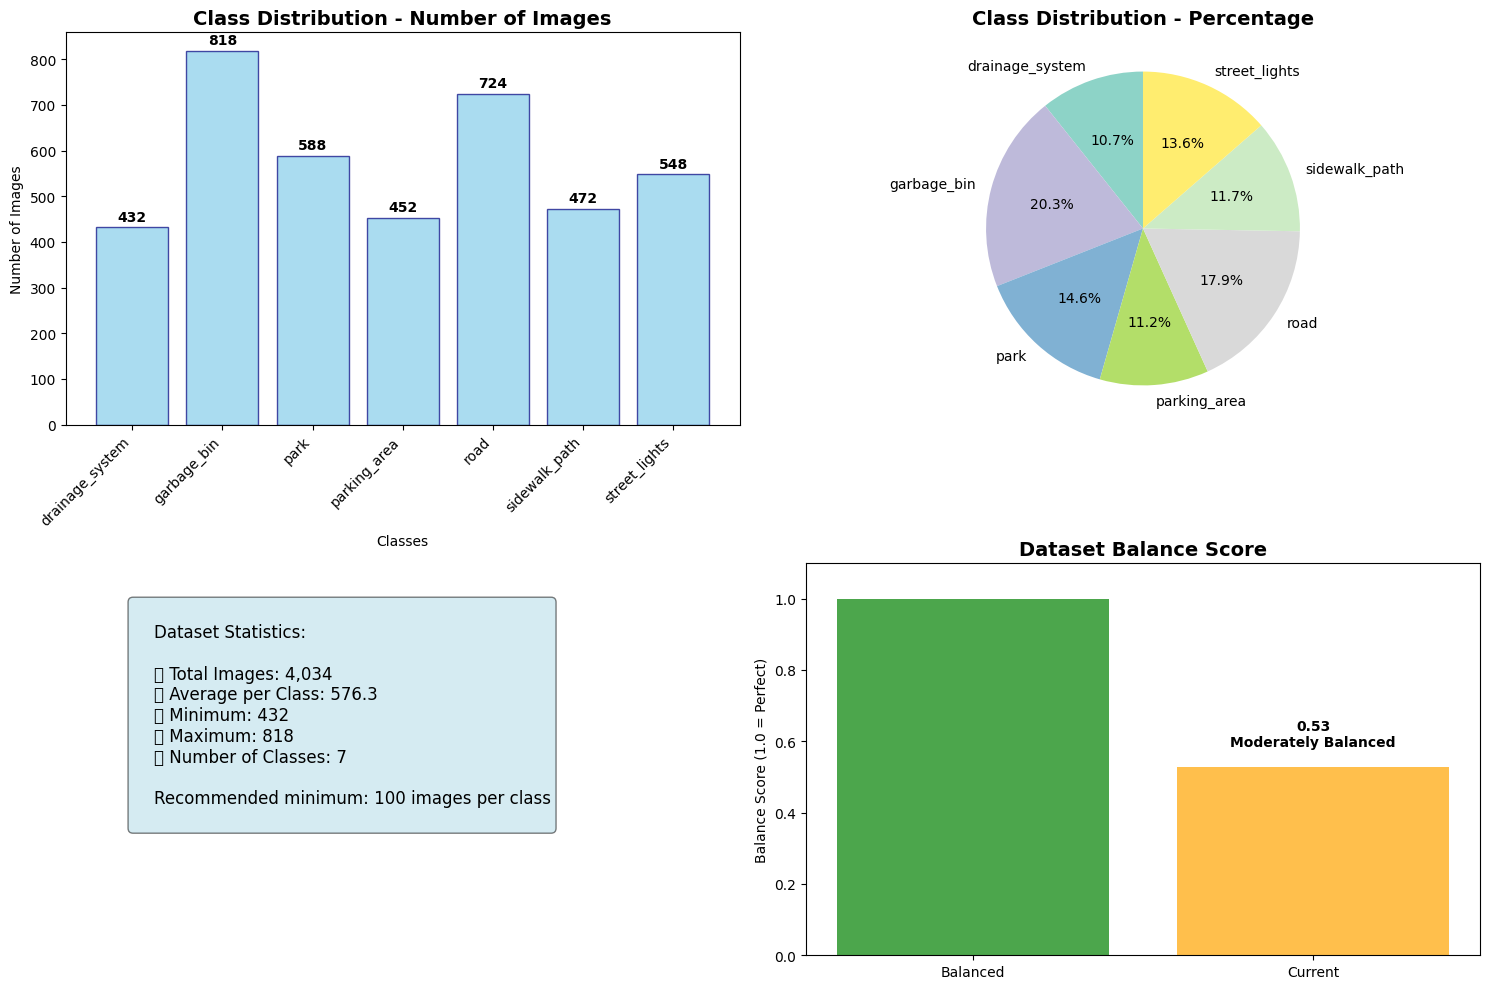

✅ Dataset validation completed successfully!

📂 STEP 4: Data Preprocessing and Train/Validation Split
🔄 Creating train/validation split...
🧹 Cleaned up existing processed data
📁 Created directory structure for train/validation split
✂️ Splitting and copying data...
✅ drainage_system: 345 train, 87 validation
✅ garbage_bin: 654 train, 164 validation
✅ park: 470 train, 118 validation
✅ parking_area: 361 train, 91 validation
✅ road: 579 train, 145 validation
✅ sidewalk_path: 377 train, 95 validation
✅ street_lights: 438 train, 110 validation


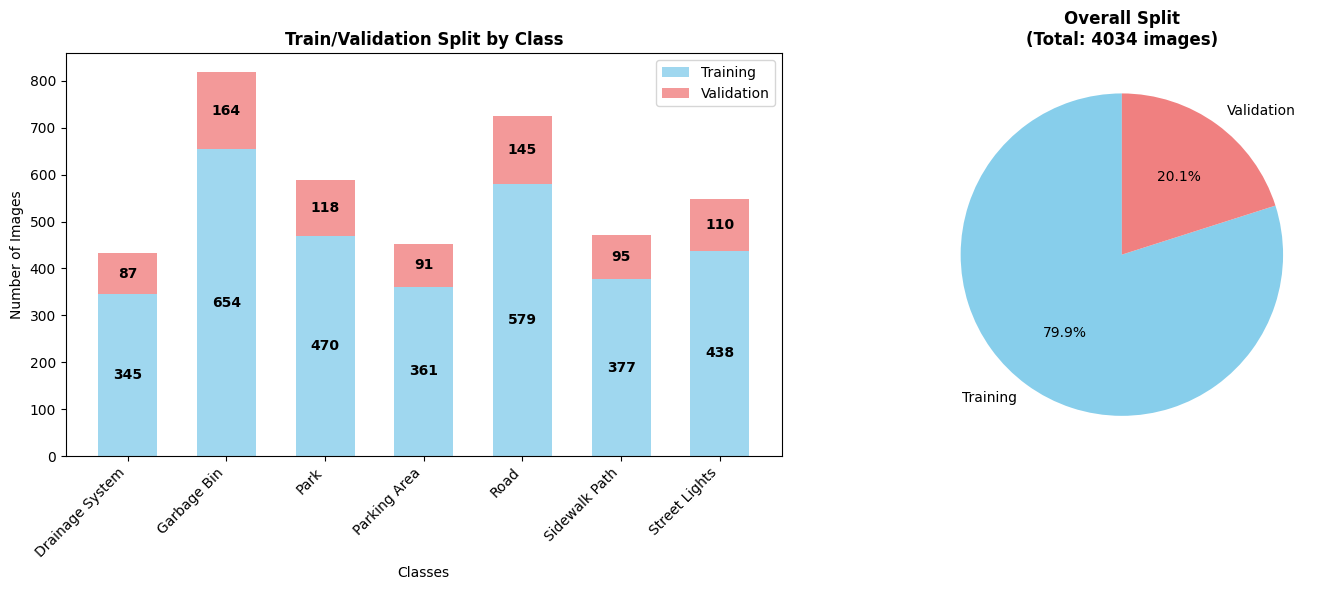


📊 Split Summary:
  🚂 Training Images: 3224
  🧪 Validation Images: 810
  📈 Total Images: 4034
  📏 Split Ratio: 80% / 20%
✅ Data preprocessing completed!

🔄 STEP 5: Creating Data Generators with Augmentation
🎨 Setting up data augmentation...
Found 1920 images belonging to 7 classes.
Found 719 images belonging to 7 classes.
🚂 Training Generator: 1920 samples
🧪 Validation Generator: 719 samples
📊 Found classes: ['drainage_system', 'garbage_bin', 'park', 'parking_area', 'road', 'sidewalk_path', 'street_lights']
👀 Visualizing data augmentation effects...


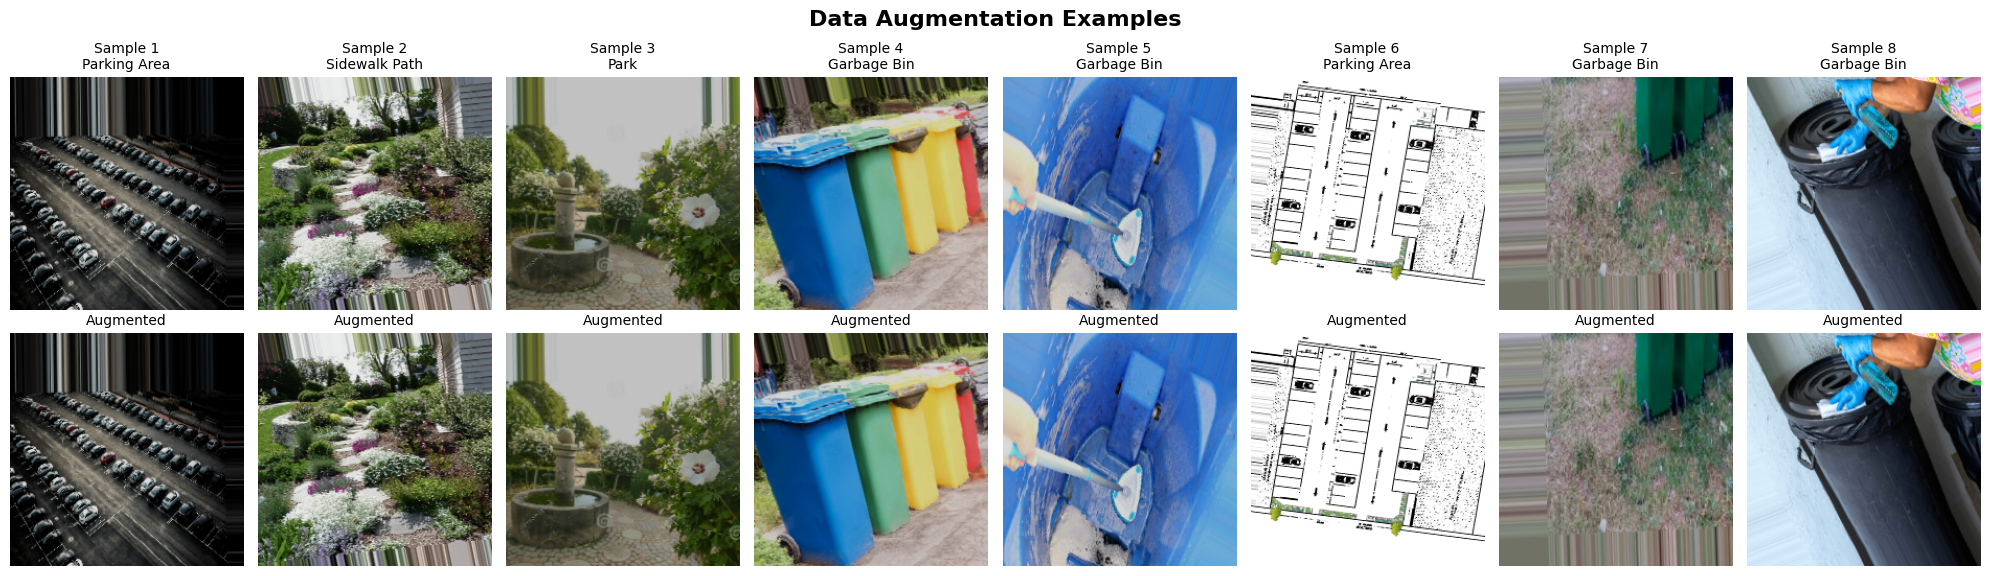

✅ Data generators created successfully!

🏗️ STEP 6: Creating Model Architecture
🔧 Building model architecture...


TypeError: EfficientNetB0() got an unexpected keyword argument 'drop_connect_rate'

In [1]:
# ================================================================================
# CIVIC CATEGORIES MULTI-CLASS CLASSIFIER - COMPLETE STEP BY STEP GUIDE
# From Data Preprocessing to TFLite Model Conversion
# 7 Classes: drainage_system, garbage_bin, park, parking_area, road, sidewalk_path, street_lights
# ================================================================================

# STEP 1: IMPORT ALL REQUIRED LIBRARIES
# ================================================================================
print("🚀 STEP 1: Importing Required Libraries")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import shutil
from PIL import Image
import random
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("✅ All libraries imported successfully!")
print(f"📊 TensorFlow Version: {tf.__version__}")
print(f"🔥 GPU Available: {len(tf.config.experimental.list_physical_devices('GPU')) > 0}")

# ================================================================================
# STEP 2: CONFIGURATION AND SETUP
# ================================================================================
print("\n🔧 STEP 2: Configuration Setup")
print("=" * 60)

class Config:
    """Configuration class for the classifier"""
    
    # Dataset Configuration
    DATA_DIR = "civic_categories"  # Your main data folder
    PROCESSED_DIR = "processed_data"  # Where we'll create train/val split
    
    # Model Configuration
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 25
    VALIDATION_SPLIT = 0.2
    
    # Class names - UPDATE THESE TO MATCH YOUR FOLDER NAMES EXACTLY
    CLASS_NAMES = [
        'drainage_system',
        'garbage_bin',
        'park', 
        'parking_area',
        'road',
        'sidewalk_path',
        'street_lights'
    ]
    
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Training Configuration
    INITIAL_LR = 0.001
    FINE_TUNE_LR = 0.0001
    
    # Model Save Paths
    MODEL_H5 = 'civic_classifier.h5'
    MODEL_TFLITE = 'civic_classifier.tflite'
    MODEL_QUANTIZED_TFLITE = 'civic_classifier_quantized.tflite'

config = Config()

print(f"📂 Data Directory: {config.DATA_DIR}")
print(f"🎯 Classes ({config.NUM_CLASSES}): {config.CLASS_NAMES}")
print(f"🖼️ Image Size: {config.IMG_SIZE}")
print(f"📦 Batch Size: {config.BATCH_SIZE}")
print(f"🔄 Max Epochs: {config.EPOCHS}")

# ================================================================================
# STEP 3: DATA EXPLORATION AND VALIDATION
# ================================================================================
print("\n🔍 STEP 3: Data Exploration and Validation")
print("=" * 60)

def explore_dataset():
    """Explore the dataset structure and show statistics"""
    
    print("📊 Analyzing dataset structure...")
    
    if not os.path.exists(config.DATA_DIR):
        print(f"❌ ERROR: Directory '{config.DATA_DIR}' not found!")
        print("Please make sure your data folder exists with the following structure:")
        print("civic_categories/")
        for class_name in config.CLASS_NAMES:
            print(f"  ├── {class_name}/")
        return False
    
    # Collect dataset statistics
    dataset_stats = {}
    total_images = 0
    
    # Supported image extensions
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp']
    
    for class_name in config.CLASS_NAMES:
        class_path = os.path.join(config.DATA_DIR, class_name)
        
        if not os.path.exists(class_path):
            print(f"❌ WARNING: Class folder '{class_name}' not found!")
            dataset_stats[class_name] = 0
            continue
        
        # Count images in this class
        image_count = 0
        for ext in image_extensions:
            pattern = os.path.join(class_path, f"*{ext}")
            image_count += len(glob.glob(pattern, recursive=False))
            # Also check uppercase extensions
            pattern = os.path.join(class_path, f"*{ext.upper()}")
            image_count += len(glob.glob(pattern, recursive=False))
        
        dataset_stats[class_name] = image_count
        total_images += image_count
        
        print(f"✅ {class_name}: {image_count} images")
    
    print(f"\n📈 Total Images: {total_images}")
    
    if total_images == 0:
        print("❌ ERROR: No images found in the dataset!")
        return False
    
    # Visualize class distribution
    plt.figure(figsize=(15, 10))
    
    # Bar plot
    plt.subplot(2, 2, 1)
    classes = list(dataset_stats.keys())
    counts = list(dataset_stats.values())
    
    bars = plt.bar(classes, counts, color='skyblue', edgecolor='navy', alpha=0.7)
    plt.title('Class Distribution - Number of Images', fontsize=14, fontweight='bold')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(count), ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    plt.subplot(2, 2, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))
    wedges, texts, autotexts = plt.pie(counts, labels=classes, autopct='%1.1f%%', 
                                      colors=colors, startangle=90)
    plt.title('Class Distribution - Percentage', fontsize=14, fontweight='bold')
    
    # Statistics table
    plt.subplot(2, 2, 3)
    plt.axis('off')
    
    # Create statistics
    min_images = min(counts) if counts else 0
    max_images = max(counts) if counts else 0
    avg_images = total_images / len(classes) if classes else 0
    
    stats_text = f"""
    Dataset Statistics:
    
    📊 Total Images: {total_images:,}
    📈 Average per Class: {avg_images:.1f}
    📉 Minimum: {min_images}
    📈 Maximum: {max_images}
    🎯 Number of Classes: {len(classes)}
    
    Recommended minimum: 100 images per class
    """
    
    plt.text(0.1, 0.9, stats_text, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))
    
    # Class balance analysis
    plt.subplot(2, 2, 4)
    if counts:
        balance_ratio = min(counts) / max(counts) if max(counts) > 0 else 0
        
        plt.bar(['Balanced', 'Current'], [1.0, balance_ratio], 
                color=['green', 'orange' if balance_ratio > 0.5 else 'red'],
                alpha=0.7)
        plt.title('Dataset Balance Score', fontsize=14, fontweight='bold')
        plt.ylabel('Balance Score (1.0 = Perfect)')
        plt.ylim(0, 1.1)
        
        # Add text annotation
        balance_text = "Well Balanced" if balance_ratio > 0.7 else "Moderately Balanced" if balance_ratio > 0.4 else "Imbalanced"
        plt.text(1, balance_ratio + 0.05, f'{balance_ratio:.2f}\n{balance_text}', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Check for minimum requirements
    min_threshold = 20  # Minimum images per class
    insufficient_classes = [cls for cls, count in dataset_stats.items() if count < min_threshold]
    
    if insufficient_classes:
        print(f"\n⚠️ WARNING: Classes with fewer than {min_threshold} images:")
        for cls in insufficient_classes:
            print(f"   • {cls}: {dataset_stats[cls]} images")
        print("Consider adding more images to these classes for better performance.")
    
    return total_images > 0

# Run dataset exploration
dataset_valid = explore_dataset()

if not dataset_valid:
    print("❌ Please fix dataset issues before proceeding!")
else:
    print("✅ Dataset validation completed successfully!")

# ================================================================================
# STEP 4: DATA PREPROCESSING AND TRAIN/VALIDATION SPLIT
# ================================================================================
print("\n📂 STEP 4: Data Preprocessing and Train/Validation Split")
print("=" * 60)

def create_train_val_directories():
    """Create organized train/validation directory structure"""
    
    print("🔄 Creating train/validation split...")
    
    # Create base directories
    train_dir = os.path.join(config.PROCESSED_DIR, 'train')
    val_dir = os.path.join(config.PROCESSED_DIR, 'validation')
    
    # Clean up existing processed data
    if os.path.exists(config.PROCESSED_DIR):
        shutil.rmtree(config.PROCESSED_DIR)
        print("🧹 Cleaned up existing processed data")
    
    # Create directory structure
    for base_dir in [train_dir, val_dir]:
        for class_name in config.CLASS_NAMES:
            class_dir = os.path.join(base_dir, class_name)
            os.makedirs(class_dir, exist_ok=True)
    
    print("📁 Created directory structure for train/validation split")
    
    return train_dir, val_dir

def split_and_copy_data(train_dir, val_dir):
    """Split data into train/validation sets and copy files"""
    
    print("✂️ Splitting and copying data...")
    
    # Supported extensions
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.webp']
    
    split_summary = {}
    
    for class_name in config.CLASS_NAMES:
        source_dir = os.path.join(config.DATA_DIR, class_name)
        
        if not os.path.exists(source_dir):
            print(f"⚠️ Skipping {class_name} - directory not found")
            continue
        
        # Collect all image files
        all_images = []
        for ext in image_extensions:
            # Lowercase extensions
            pattern = os.path.join(source_dir, ext)
            all_images.extend(glob.glob(pattern))
            # Uppercase extensions
            pattern = os.path.join(source_dir, ext.upper())
            all_images.extend(glob.glob(pattern))
        
        if len(all_images) == 0:
            print(f"⚠️ No images found in {class_name}")
            continue
        
        # Shuffle images for random split
        random.shuffle(all_images)
        
        # Split into train/validation
        split_idx = int(len(all_images) * (1 - config.VALIDATION_SPLIT))
        train_images = all_images[:split_idx]
        val_images = all_images[split_idx:]
        
        # Copy training images
        train_class_dir = os.path.join(train_dir, class_name)
        for img_path in train_images:
            filename = os.path.basename(img_path)
            dest_path = os.path.join(train_class_dir, filename)
            shutil.copy2(img_path, dest_path)
        
        # Copy validation images
        val_class_dir = os.path.join(val_dir, class_name)
        for img_path in val_images:
            filename = os.path.basename(img_path)
            dest_path = os.path.join(val_class_dir, filename)
            shutil.copy2(img_path, dest_path)
        
        split_summary[class_name] = {
            'total': len(all_images),
            'train': len(train_images),
            'validation': len(val_images)
        }
        
        print(f"✅ {class_name}: {len(train_images)} train, {len(val_images)} validation")
    
    return split_summary

def visualize_split_summary(split_summary):
    """Visualize the train/validation split"""
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    classes = list(split_summary.keys())
    train_counts = [split_summary[cls]['train'] for cls in classes]
    val_counts = [split_summary[cls]['validation'] for cls in classes]
    
    # Stacked bar chart
    x = np.arange(len(classes))
    width = 0.6
    
    bars1 = axes[0].bar(x, train_counts, width, label='Training', color='skyblue', alpha=0.8)
    bars2 = axes[0].bar(x, val_counts, width, bottom=train_counts, label='Validation', color='lightcoral', alpha=0.8)
    
    axes[0].set_xlabel('Classes')
    axes[0].set_ylabel('Number of Images')
    axes[0].set_title('Train/Validation Split by Class', fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([cls.replace('_', ' ').title() for cls in classes], rotation=45, ha='right')
    axes[0].legend()
    
    # Add value labels
    for i, (train, val) in enumerate(zip(train_counts, val_counts)):
        axes[0].text(i, train/2, str(train), ha='center', va='center', fontweight='bold')
        axes[0].text(i, train + val/2, str(val), ha='center', va='center', fontweight='bold')
    
    # Summary statistics
    total_train = sum(train_counts)
    total_val = sum(val_counts)
    total_images = total_train + total_val
    
    # Pie chart for overall split
    sizes = [total_train, total_val]
    labels = ['Training', 'Validation']
    colors = ['skyblue', 'lightcoral']
    
    axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Overall Split\n(Total: {total_images} images)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Split Summary:")
    print(f"  🚂 Training Images: {total_train}")
    print(f"  🧪 Validation Images: {total_val}")
    print(f"  📈 Total Images: {total_images}")
    print(f"  📏 Split Ratio: {(1-config.VALIDATION_SPLIT)*100:.0f}% / {config.VALIDATION_SPLIT*100:.0f}%")

# Execute data preprocessing
if dataset_valid:
    train_dir, val_dir = create_train_val_directories()
    split_summary = split_and_copy_data(train_dir, val_dir)
    visualize_split_summary(split_summary)
    print("✅ Data preprocessing completed!")

# ================================================================================
# STEP 5: DATA GENERATORS WITH AUGMENTATION
# ================================================================================
print("\n🔄 STEP 5: Creating Data Generators with Augmentation")
print("=" * 60)

def create_data_generators(train_dir, val_dir):
    """Create data generators with augmentation for training and validation"""
    
    print("🎨 Setting up data augmentation...")
    
    # Training data generator with comprehensive augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,                    # Normalize pixel values
        rotation_range=30,                 # Random rotation up to 30 degrees
        width_shift_range=0.25,            # Random horizontal shift
        height_shift_range=0.25,           # Random vertical shift
        horizontal_flip=True,              # Random horizontal flip
        zoom_range=0.3,                    # Random zoom
        shear_range=0.2,                   # Random shear transformation
        brightness_range=[0.7, 1.3],       # Random brightness adjustment
        channel_shift_range=0.1,           # Random channel shift
        fill_mode='nearest'                # Fill strategy for transformations
    )
    
    # Validation data generator (only rescaling)
    val_datagen = ImageDataGenerator(rescale=1./255)
    
    # Create training generator
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=config.IMG_SIZE,
        batch_size=config.BATCH_SIZE,
        class_mode='categorical',
        classes=config.CLASS_NAMES,
        shuffle=True,
        seed=42
    )
    
    # Create validation generator
    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=config.IMG_SIZE,
        batch_size=config.BATCH_SIZE,
        class_mode='categorical',
        classes=config.CLASS_NAMES,
        shuffle=False,
        seed=42
    )
    
    print(f"🚂 Training Generator: {train_generator.samples} samples")
    print(f"🧪 Validation Generator: {val_generator.samples} samples")
    print(f"📊 Found classes: {list(train_generator.class_indices.keys())}")
    
    return train_generator, val_generator

def visualize_augmentation(train_generator):
    """Visualize data augmentation effects"""
    
    print("👀 Visualizing data augmentation effects...")
    
    # Get a batch of data
    batch_x, batch_y = next(train_generator)
    
    # Display original and augmented versions
    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    fig.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold')
    
    for i in range(8):
        # Original image (first row)
        axes[0, i].imshow(batch_x[i])
        class_idx = np.argmax(batch_y[i])
        class_name = config.CLASS_NAMES[class_idx].replace('_', ' ').title()
        axes[0, i].set_title(f'Sample {i+1}\n{class_name}', fontsize=10)
        axes[0, i].axis('off')
        
        # Get another augmented version (second row)
        if i < len(batch_x):
            axes[1, i].imshow(batch_x[i])
            axes[1, i].set_title('Augmented', fontsize=10)
            axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Create data generators
if dataset_valid:
    train_generator, val_generator = create_data_generators(train_dir, val_dir)
    
    # Show augmentation examples
    visualize_augmentation(train_generator)
    
    print("✅ Data generators created successfully!")




🏗️ STEP 6: Creating Model Architecture
🔧 Building model architecture...
2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📊 Base model loaded: MobileNetV2
🔒 Base model frozen: 154 layers
🎯 Classification head added
📈 Output classes: 7
⚙️ Model compiled with Adam optimizer and Top-2 accuracy
📊 Learning rate: 0.001
🎯 Loss function: categorical_crossentropy

📋 Model Architecture Summary:


Model: "civic_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_0.35_224 (Functional)    │ (None, 7, 7, 1280)          │         410,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_avg_pooling                   │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_1 (BatchNormalization)            │ (None, 1280)                │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_2 (BatchNormalization)            │ (None, 512)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_3 (BatchNormalization)            │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,207,399 (4.61 MB)

 Trainable params: 793,095 (3.03 MB)

...

60/60 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.8641 - loss: 0.3976 - top_2_accuracy: 0.9578 - val_accuracy: 0.9616 - val_loss: 0.1163 - val_top_2_accuracy: 0.9886 - learning_rate: 0.0010
Epoch 17/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8616 - loss: 0.4097 - top_2_accuracy: 0.9604
Epoch 17: val_accuracy improved from 0.96165 to 0.96733, saving model to best_model_checkpoint.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.8609 - loss: 0.4092 - top_2_accuracy: 0.9594 - val_accuracy: 0.9673 - val_loss: 0.1129 - val_top_2_accuracy: 0.9957 - learning_rate: 0.0010
Epoch 18/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8677 - loss: 0.3715 - top_2_accuracy: 0.9601
Epoch 18: val_accuracy did not improve from 0.96733
60/60 ━━━━━━━━━━━━━━━━━━━━ 211s 4s/step - accuracy: 0.8677 - loss: 0.3697 - top_2_accuracy: 0.9641 - val_accuracy: 0.9531 - val_loss: 0.1302 - val_top_2_accuracy: 0.9943 - learning_rate: 0.0010
Epoch 19/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8591 - loss: 0.4002 - top_2_accuracy: 0.9511
Epoch 19: val_accuracy did not improve from 0.96733
60/60 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.8620 - loss: 0.3990 - top_2_accuracy: 0.9573 - val_accuracy: 0.9645 - val_loss: 0.1265 - val_top_2_accuracy: 0.9886 - learning_rate: 0.0010
Epoch 20/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8860 - loss: 0.3490 - top_2_accu

60/60 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.8823 - loss: 0.3374 - top_2_accuracy: 0.9672 - val_accuracy: 0.9702 - val_loss: 0.1067 - val_top_2_accuracy: 0.9972 - learning_rate: 3.0000e-04
Epoch 23/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8898 - loss: 0.3032 - top_2_accuracy: 0.9587
Epoch 23: val_accuracy improved from 0.97017 to 0.97301, saving model to best_model_checkpoint.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8901 - loss: 0.3103 - top_2_accuracy: 0.9646 - val_accuracy: 0.9730 - val_loss: 0.1026 - val_top_2_accuracy: 0.9986 - learning_rate: 3.0000e-04
Epoch 24/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8934 - loss: 0.3205 - top_2_accuracy: 0.9702
Epoch 24: val_accuracy did not improve from 0.97301
60/60 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.8896 - loss: 0.3283 - top_2_accuracy: 0.9698 - val_accuracy: 0.9730 - val_loss: 0.0955 - val_top_2_accuracy: 0.9957 - learning_rate: 3.0000e-04
Epoch 25/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8941 - loss: 0.3051 - top_2_accuracy: 0.9712
Epoch 25: val_accuracy improved from 0.97301 to 0.97727, saving model to best_model_checkpoint.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.8969 - loss: 0.3020 - top_2_accuracy: 0.9682 - val_accuracy: 0.9773 - val_loss: 0.0924 - val_top_2_accuracy: 0.9986 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 25.
✅ Initial training completed!
📊 Generating training history plots...


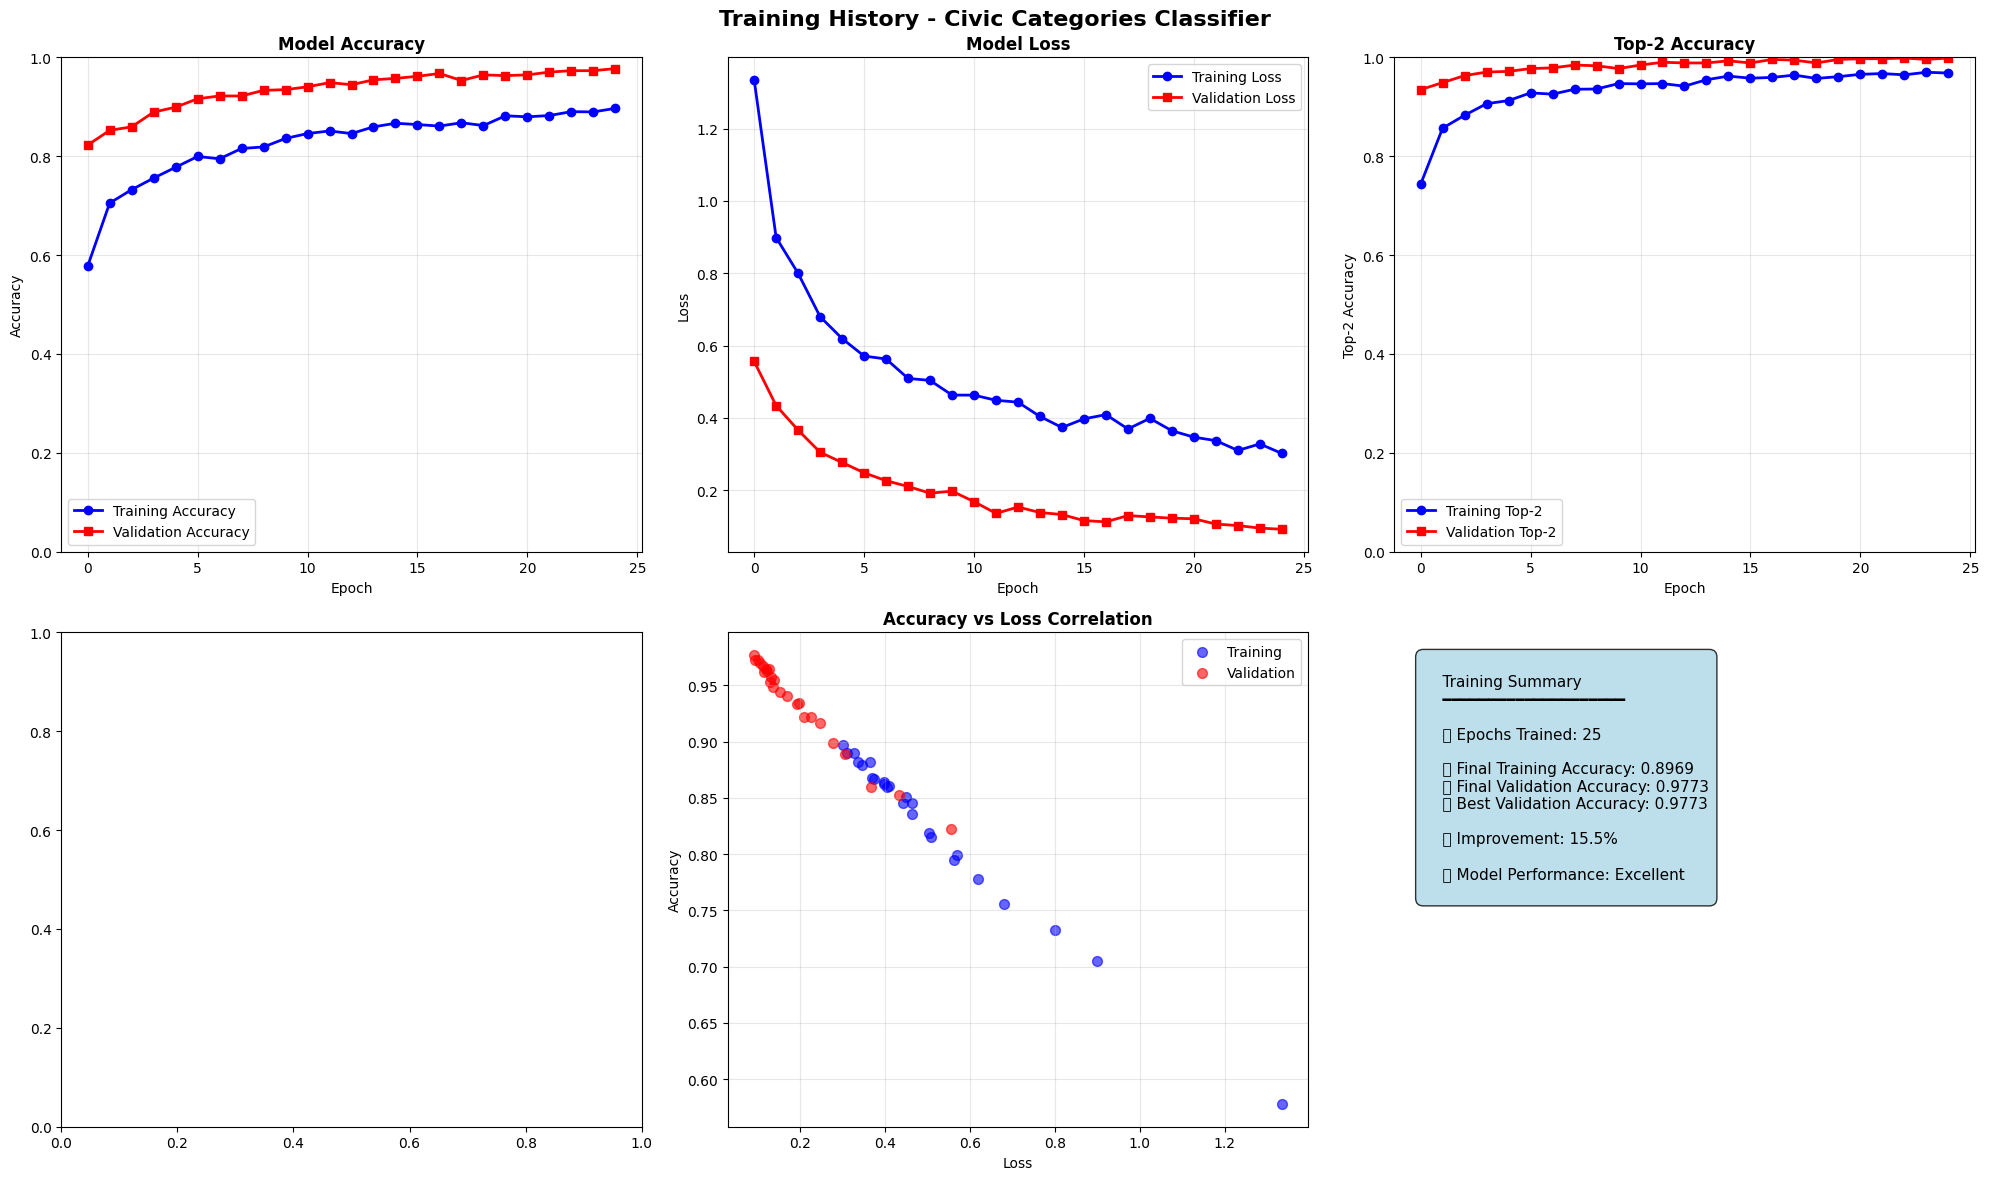

✅ Training completed! Best validation accuracy: 0.9773

🔧 STEP 9: Fine-tuning Model for Enhanced Performance
🔓 Unfreezing top layers of base model for fine-tuning...
🔓 Unfroze top 30 layers
🔒 Kept 124 layers frozen
⚙️ Model compiled with Adam optimizer and Top-2 accuracy
📊 Learning rate: 0.0001
🎯 Loss function: categorical_crossentropy
🚀 Starting fine-tuning...
Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8143 - loss: 0.5364 - top_2_accuracy: 0.9339
Epoch 1: val_accuracy improved from None to 0.95881, saving model to fine_tuned_best_model.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.8318 - loss: 0.4945 - top_2_accuracy: 0.9417 - val_accuracy: 0.9588 - val_loss: 0.1313 - val_top_2_accuracy: 0.9957 - learning_rate: 1.0000e-04
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8269 - loss: 0.4986 - top_2_accuracy: 0.9411
Epoch 2: val_accuracy did not improve from 0.95881
60/60 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.8406 - loss: 0.4664 - top_2_accuracy: 0.9490 - val_accuracy: 0.9531 - val_loss: 0.1412 - val_top_2_accuracy: 0.9943 - learning_rate: 1.0000e-04
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8570 - loss: 0.3985 - top_2_accuracy: 0.9579
Epoch 3: val_accuracy did not improve from 0.95881
60/60 ━━━━━━━━━━━━━━━━━━━━ 192s 3s/step - accuracy: 0.8630 - loss: 0.3772 - top_2_accuracy: 0.9599 - val_accuracy: 0.9432 - val_loss: 0.1476 - val_top_2_accuracy: 0.9929 - learning_rate: 1.0000e-04
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8633 - loss: 0.4037 - top

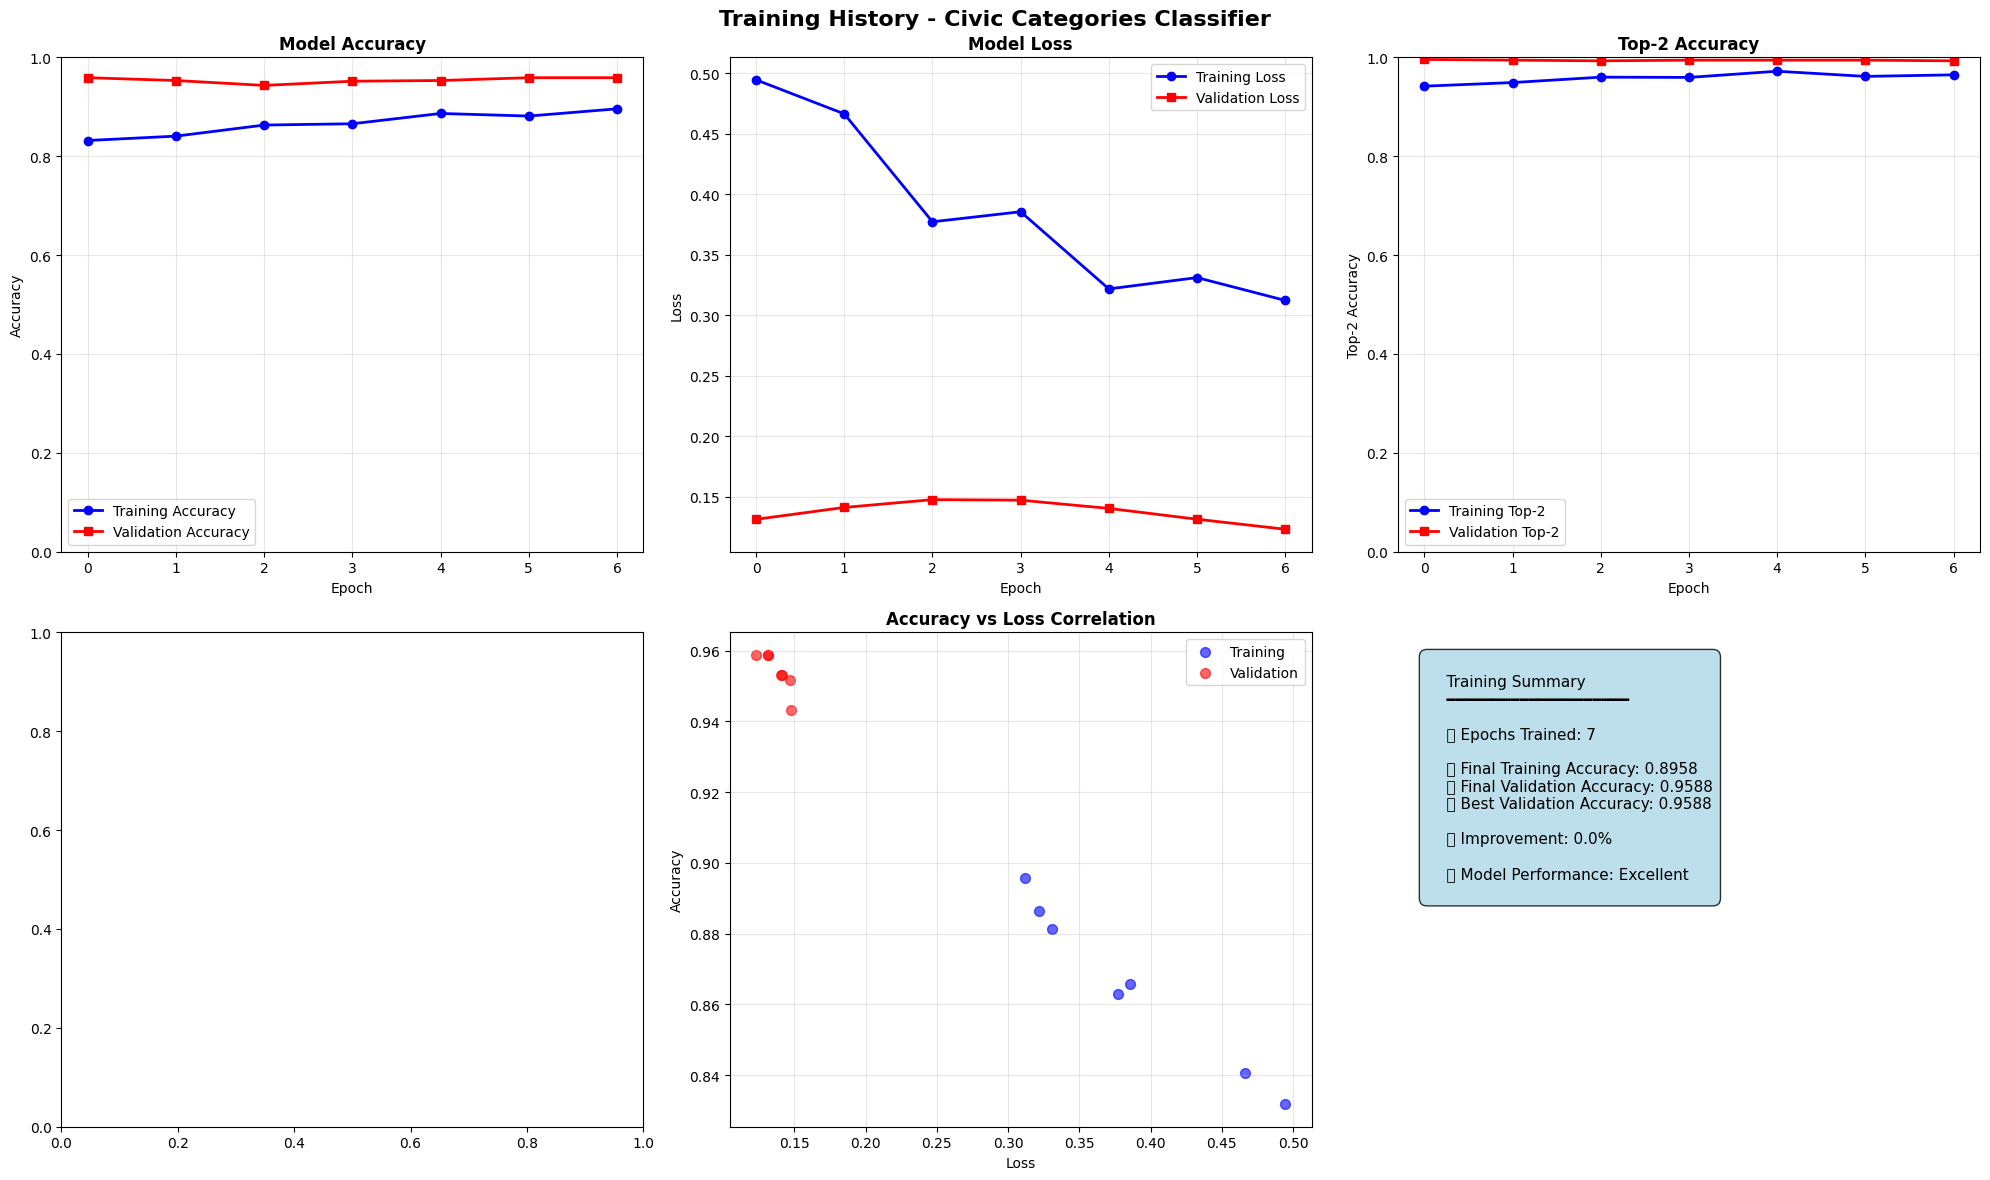

🎯 Fine-tuned validation accuracy: 0.9588

📊 STEP 10: Model Evaluation and Analysis
🧪 Evaluating model performance...
🔄 Generating predictions...
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step
🎯 Overall Accuracy: 0.9597


NameError: name 'has_top_k' is not defined

In [7]:
# ================================================================================
# STEP 6: MODEL ARCHITECTURE CREATION
# ================================================================================
print("\n🏗️ STEP 6: Creating Model Architecture")
print("=" * 60)
from tensorflow.keras.applications import MobileNetV2

def create_base_model():
    """Create the base model using EfficientNetB0 with transfer learning"""
    
    print("🔧 Building model architecture...")
    
    # Load pre-trained MobileNetV2
    base_model = MobileNetV2(
        weights='imagenet',           # Use pre-trained ImageNet weights
        include_top=False,           # Exclude the final classification layer
        input_shape=(*config.IMG_SIZE, 3),
        alpha=0.35        # Dropout for regularization
    )
    
    # Freeze the base model initially
    base_model.trainable = False
    
    print(f"📊 Base model loaded: MobileNetV2")
    print(f"🔒 Base model frozen: {len(base_model.layers)} layers")
    
    return base_model

def build_classification_head(base_model):
    """Build the custom classification head"""
    
    # Create the complete model
    inputs = keras.Input(shape=(*config.IMG_SIZE, 3))
    
    # Base model
    x = base_model(inputs, training=False)
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D(name='global_avg_pooling')(x)
    
    # Batch normalization
    x = layers.BatchNormalization(name='bn_1')(x)
    
    # Dropout for regularization
    x = layers.Dropout(0.3, name='dropout_1')(x)
    
    # First dense layer
    x = layers.Dense(512, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.4, name='dropout_2')(x)
    
    # Second dense layer
    x = layers.Dense(256, activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Dropout(0.3, name='dropout_3')(x)
    
    # Output layer
    outputs = layers.Dense(config.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    # Create the model
    model = keras.Model(inputs, outputs, name='civic_classifier')
    
    print(f"🎯 Classification head added")
    print(f"📈 Output classes: {config.NUM_CLASSES}")
    
    return model

def compile_model(model, learning_rate=None):
    """Compile the model with optimizer, loss, and metrics"""
    
    if learning_rate is None:
        learning_rate = config.INITIAL_LR
    
    # Advanced optimizer with better convergence
    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7
    )
    
    # Try to use top_k_categorical_accuracy, fallback to basic accuracy if not available
    try:
        # Try modern metric first
        metrics = ['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=metrics
        )
        print(f"⚙️ Model compiled with Adam optimizer and Top-2 accuracy")
    except:
        # Fallback to basic metrics for older TF versions
        print("⚠️ Using basic accuracy metric (Top-2 not available in this TF version)")
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        print(f"⚙️ Model compiled with Adam optimizer (basic accuracy only)")
    
    print(f"📊 Learning rate: {learning_rate}")
    print(f"🎯 Loss function: categorical_crossentropy")
    
    return model

def display_model_architecture(model):
    """Display detailed model information"""
    
    print("\n📋 Model Architecture Summary:")
    print("=" * 50)
    
    model.summary()
    
    # Count parameters
    total_params = model.count_params()
    trainable_params = sum([keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    
    print(f"\n📊 Parameter Summary:")
    print(f"  🔢 Total Parameters: {total_params:,}")
    print(f"  🔓 Trainable Parameters: {trainable_params:,}")
    print(f"  🔒 Non-trainable Parameters: {non_trainable_params:,}")
    
    # Create architecture visualization
    keras.utils.plot_model(
        model, 
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        expand_nested=False,
        dpi=96
    )
    print("💾 Model architecture saved as 'model_architecture.png'")

# Build the model
if dataset_valid:
    base_model = create_base_model()
    model = build_classification_head(base_model)
    model = compile_model(model)
    display_model_architecture(model)
    
    print("✅ Model architecture created successfully!")

# ================================================================================
# STEP 7: TRAINING CALLBACKS AND CONFIGURATION
# ================================================================================
print("\n⚙️ STEP 7: Setting up Training Callbacks")
print("=" * 60)

def create_callbacks():
    """Create training callbacks for monitoring and optimization"""
    
    callbacks = [
        # Early stopping to prevent overfitting
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=8,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001,
            mode='max'
        ),
        
        # Reduce learning rate when plateau is reached
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1,
            cooldown=2,
            mode='min'
        ),
        
        # Save best model during training
        keras.callbacks.ModelCheckpoint(
            filepath='best_model_checkpoint.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False,
            mode='max',
            verbose=1
        ),
        
        # Log training progress to CSV
        keras.callbacks.CSVLogger(
            'training_log.csv',
            separator=',',
            append=False
        )
    ]
    
    print("📝 Created training callbacks:")
    print("  • Early Stopping (patience: 8)")
    print("  • Learning Rate Reduction (factor: 0.3, patience: 4)")
    print("  • Model Checkpoint (save best model)")
    print("  • CSV Logger (training metrics)")
    
    return callbacks

# Create callbacks
callbacks = create_callbacks()
print("✅ Training callbacks configured!")

# ================================================================================
# STEP 8: MODEL TRAINING
# ================================================================================
print("\n🚀 STEP 8: Model Training")
print("=" * 60)

def train_model(model, train_generator, val_generator, callbacks):
    """Train the model with transfer learning"""
    
    print("🚂 Starting initial training (frozen base model)...")
    print(f"📊 Training samples: {train_generator.samples}")
    print(f"🧪 Validation samples: {val_generator.samples}")
    print(f"⏱️ Maximum epochs: {config.EPOCHS}")
    
    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // config.BATCH_SIZE,
        epochs=config.EPOCHS,
        validation_data=val_generator,
        validation_steps=val_generator.samples // config.BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    
    print("✅ Initial training completed!")
    
    return history

def plot_training_history(history):
    """Plot comprehensive training history"""
    
    print("📊 Generating training history plots...")
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Training History - Civic Categories Classifier', fontsize=16, fontweight='bold')
    
    # Training and validation accuracy
    axes[0, 0].plot(history.history['accuracy'], 'b-', linewidth=2, label='Training Accuracy', marker='o')
    axes[0, 0].plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy', marker='s')
    axes[0, 0].set_title('Model Accuracy', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, 1)
    
    # Training and validation loss
    axes[0, 1].plot(history.history['loss'], 'b-', linewidth=2, label='Training Loss', marker='o')
    axes[0, 1].plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss', marker='s')
    axes[0, 1].set_title('Model Loss', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Top-2 accuracy (with error handling)
    if 'top_2_accuracy' in history.history:
        axes[0, 2].plot(history.history['top_2_accuracy'], 'b-', linewidth=2, label='Training Top-2', marker='o')
        axes[0, 2].plot(history.history['val_top_2_accuracy'], 'r-', linewidth=2, label='Validation Top-2', marker='s')
        axes[0, 2].set_title('Top-2 Accuracy', fontweight='bold')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Top-2 Accuracy')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
        axes[0, 2].set_ylim(0, 1)
    else:
        # Plot validation accuracy again as fallback
        axes[0, 2].plot(history.history['accuracy'], 'b-', linewidth=2, label='Training Accuracy', marker='o')
        axes[0, 2].plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy', marker='s')
        axes[0, 2].set_title('Accuracy (Fallback)', fontweight='bold')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Accuracy')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
        axes[0, 2].set_ylim(0, 1)
    
    # Learning rate (if available)
    if 'lr' in history.history:
        axes[1, 0].plot(history.history['lr'], 'g-', linewidth=2, marker='o')
        axes[1, 0].set_title('Learning Rate', fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].set_yscale('log')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Accuracy vs Loss correlation
    axes[1, 1].scatter(history.history['loss'], history.history['accuracy'], 
                      c='blue', alpha=0.6, label='Training', s=50)
    axes[1, 1].scatter(history.history['val_loss'], history.history['val_accuracy'], 
                      c='red', alpha=0.6, label='Validation', s=50)
    axes[1, 1].set_title('Accuracy vs Loss Correlation', fontweight='bold')
    axes[1, 1].set_xlabel('Loss')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Training summary
    axes[1, 2].axis('off')
    
    # Calculate metrics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    best_val_acc = max(history.history['val_accuracy'])
    epochs_trained = len(history.history['accuracy'])
    
    summary_text = f"""
    Training Summary
    ━━━━━━━━━━━━━━━━━━━━
    
    📊 Epochs Trained: {epochs_trained}
    
    🎯 Final Training Accuracy: {final_train_acc:.4f}
    🧪 Final Validation Accuracy: {final_val_acc:.4f}
    🏆 Best Validation Accuracy: {best_val_acc:.4f}
    
    📈 Improvement: {((best_val_acc - history.history['val_accuracy'][0]) * 100):.1f}%
    
    🔥 Model Performance: {"Excellent" if best_val_acc > 0.9 else "Good" if best_val_acc > 0.8 else "Fair" if best_val_acc > 0.7 else "Needs Improvement"}
    """
    
    axes[1, 2].text(0.05, 0.95, summary_text, fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8),
                   transform=axes[1, 2].transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return final_val_acc, best_val_acc

# Execute training
if dataset_valid:
    print("🏁 Starting model training...")
    
    history = train_model(model, train_generator, val_generator, callbacks)
    final_val_acc, best_val_acc = plot_training_history(history)
    
    print(f"✅ Training completed! Best validation accuracy: {best_val_acc:.4f}")

# ================================================================================
# STEP 9: FINE-TUNING FOR BETTER ACCURACY
# ================================================================================
print("\n🔧 STEP 9: Fine-tuning Model for Enhanced Performance")
print("=" * 60)

def fine_tune_model(model, train_generator, val_generator):
    """Fine-tune the model by unfreezing some layers"""
    
    print("🔓 Unfreezing top layers of base model for fine-tuning...")
    
    # Get the base model (EfficientNet)
    base_model = model.layers[1]  # The EfficientNet layer
    
    # Unfreeze the base model
    base_model.trainable = True
    
    # Freeze all layers except the last 30
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    trainable_layers = sum([layer.trainable for layer in base_model.layers])
    print(f"🔓 Unfroze top {trainable_layers} layers")
    print(f"🔒 Kept {len(base_model.layers) - trainable_layers} layers frozen")
    
    # Recompile with lower learning rate
    model = compile_model(model, learning_rate=config.FINE_TUNE_LR)
    
    # Fine-tuning callbacks with adjusted patience
    fine_tune_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=6,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.0005,
            mode='max'
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-8,
            verbose=1,
            mode='min'
        ),
        keras.callbacks.ModelCheckpoint(
            filepath='fine_tuned_best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False,
            mode='max',
            verbose=1
        )
    ]
    
    print("🚀 Starting fine-tuning...")
    
    # Fine-tune for fewer epochs
    fine_tune_epochs = 15
    
    history_fine = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // config.BATCH_SIZE,
        epochs=fine_tune_epochs,
        validation_data=val_generator,
        validation_steps=val_generator.samples // config.BATCH_SIZE,
        callbacks=fine_tune_callbacks,
        verbose=1
    )
    
    print("✅ Fine-tuning completed!")
    
    return model, history_fine

# Execute fine-tuning
if dataset_valid:
    fine_tuned_model, fine_tune_history = fine_tune_model(model, train_generator, val_generator)
    
    print("📊 Fine-tuning results:")
    fine_val_acc, fine_best_acc = plot_training_history(fine_tune_history)
    print(f"🎯 Fine-tuned validation accuracy: {fine_best_acc:.4f}")




📊 STEP 10: Model Evaluation and Analysis
🧪 Evaluating model performance...
🔄 Generating predictions...
23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step
🎯 Overall Accuracy: 0.9597
🥈 Top-2 Accuracy: 0.9958
📈 Creating confusion matrix...


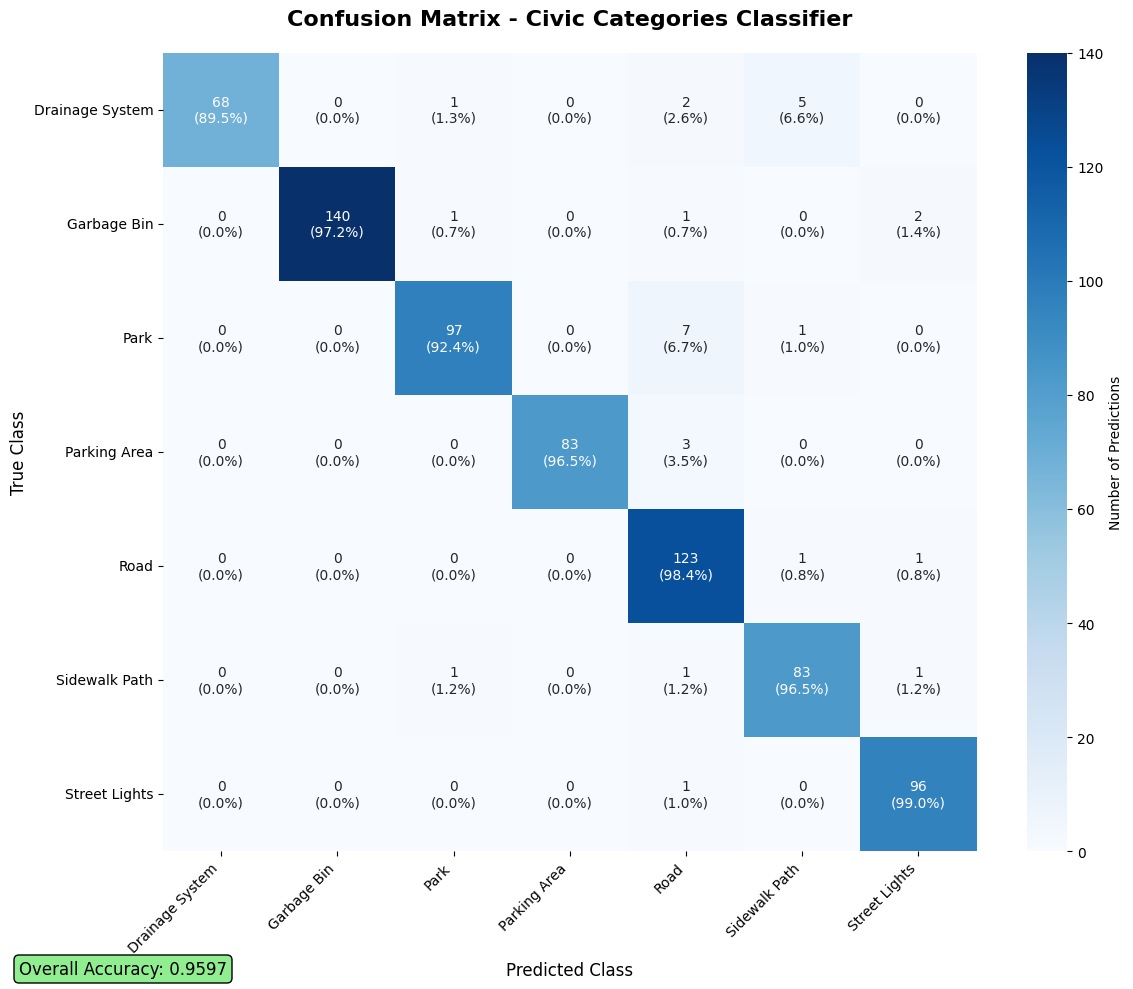

📋 Classification Report:
                 precision    recall  f1-score   support

Drainage System     1.0000    0.8947    0.9444        76
    Garbage Bin     1.0000    0.9722    0.9859       144
           Park     0.9700    0.9238    0.9463       105
   Parking Area     1.0000    0.9651    0.9822        86
           Road     0.8913    0.9840    0.9354       125
  Sidewalk Path     0.9222    0.9651    0.9432        86
  Street Lights     0.9600    0.9897    0.9746        97

       accuracy                         0.9597       719
      macro avg     0.9634    0.9564    0.9589       719
   weighted avg     0.9620    0.9597    0.9599       719

💾 Classification report saved to 'classification_report.csv'
👀 Showing 12 sample predictions...


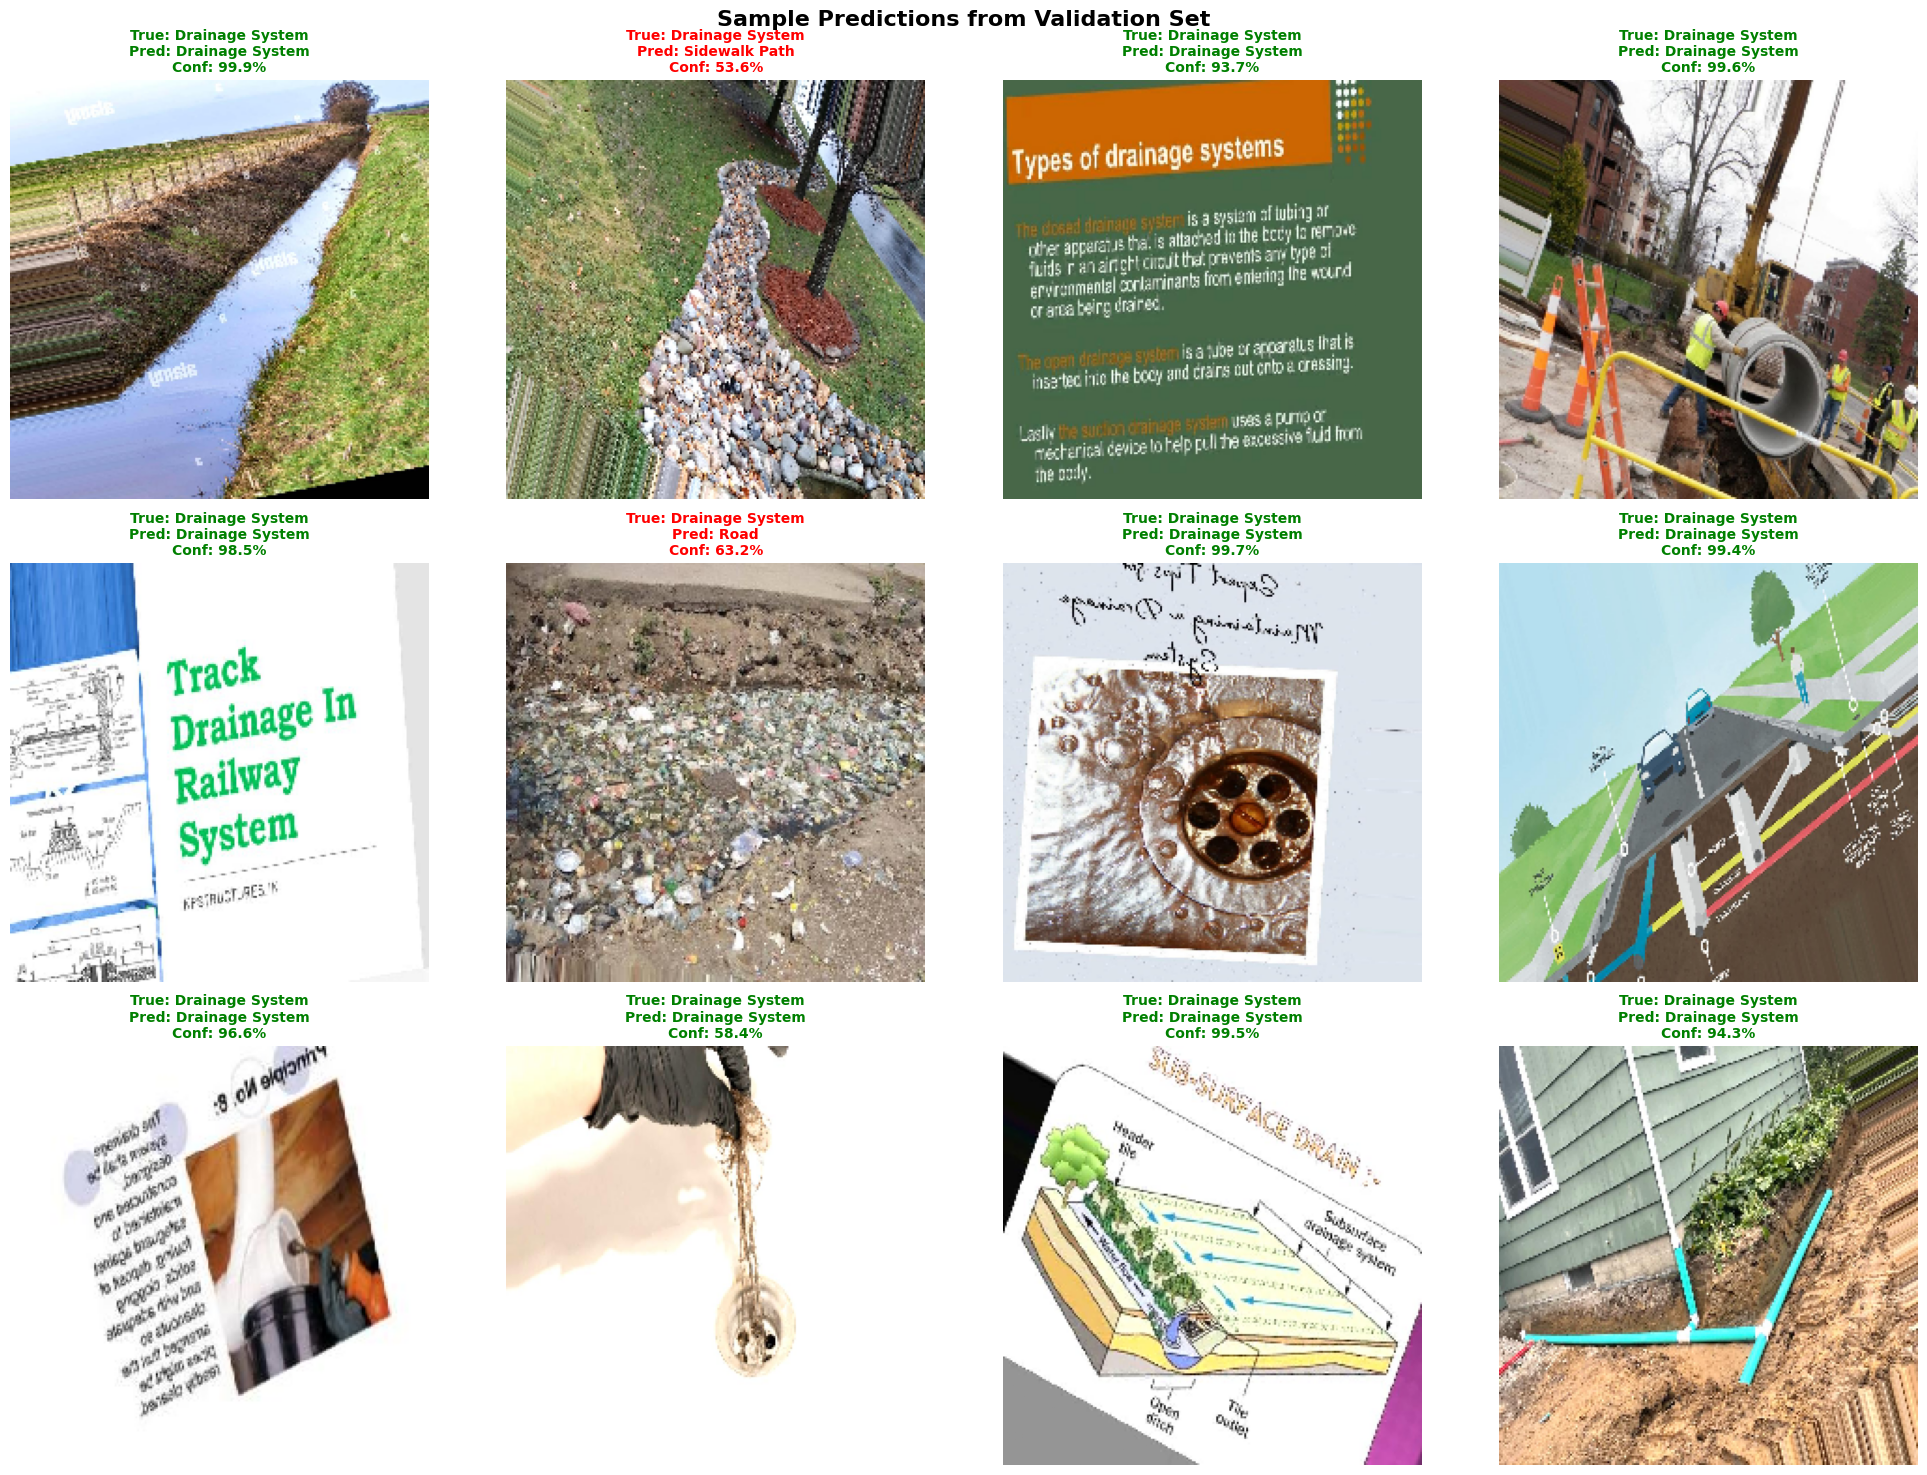


💾 STEP 11: Saving Model in Multiple Formats
💾 Saving model in H5 format...
✅ Model saved as 'civic_classifier.h5'
📊 Model size: 13.29 MB
🔄 Converting to TensorFlow Lite ...
INFO:tensorflow:Assets written to: C:\Users\tanma\AppData\Local\Temp\tmpw3g7kr71\assets


INFO:tensorflow:Assets written to: C:\Users\tanma\AppData\Local\Temp\tmpw3g7kr71\assets


Saved artifact at 'C:\Users\tanma\AppData\Local\Temp\tmpw3g7kr71'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_322')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2453886693072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365280336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365290320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454366517200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365275152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365283984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365288400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365288976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365281104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365288592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

INFO:tensorflow:Assets written to: C:\Users\tanma\AppData\Local\Temp\tmp1v1owx4d\assets


Saved artifact at 'C:\Users\tanma\AppData\Local\Temp\tmp1v1owx4d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_322')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2453886693072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365280336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365290320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454366517200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365275152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365283984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365288400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365288976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365281104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2454365288592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

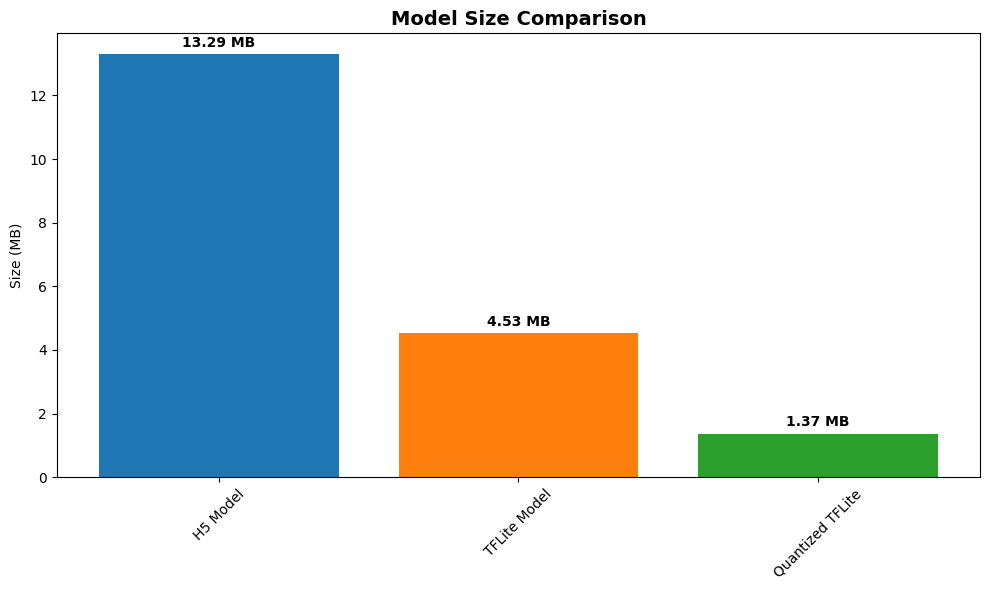


🔍 STEP 12: Custom Image Prediction Functions

📱 STEP 13: TensorFlow Lite Prediction Functions

🎮 STEP 14: Complete Usage Examples and Testing

🏁 STEP 15: Final Usage Examples
🧪 RUNNING COMPLETE TEST SUITE

📂 Test 1: Loading saved models...


✅ H5 model loaded successfully

🎲 Test 2: Random validation images...
🎲 Testing 3 random images from validation set...

🎯 Random Test #1
True Label: Drainage System
🔍 Analyzing image: temp_random_image_13.jpg


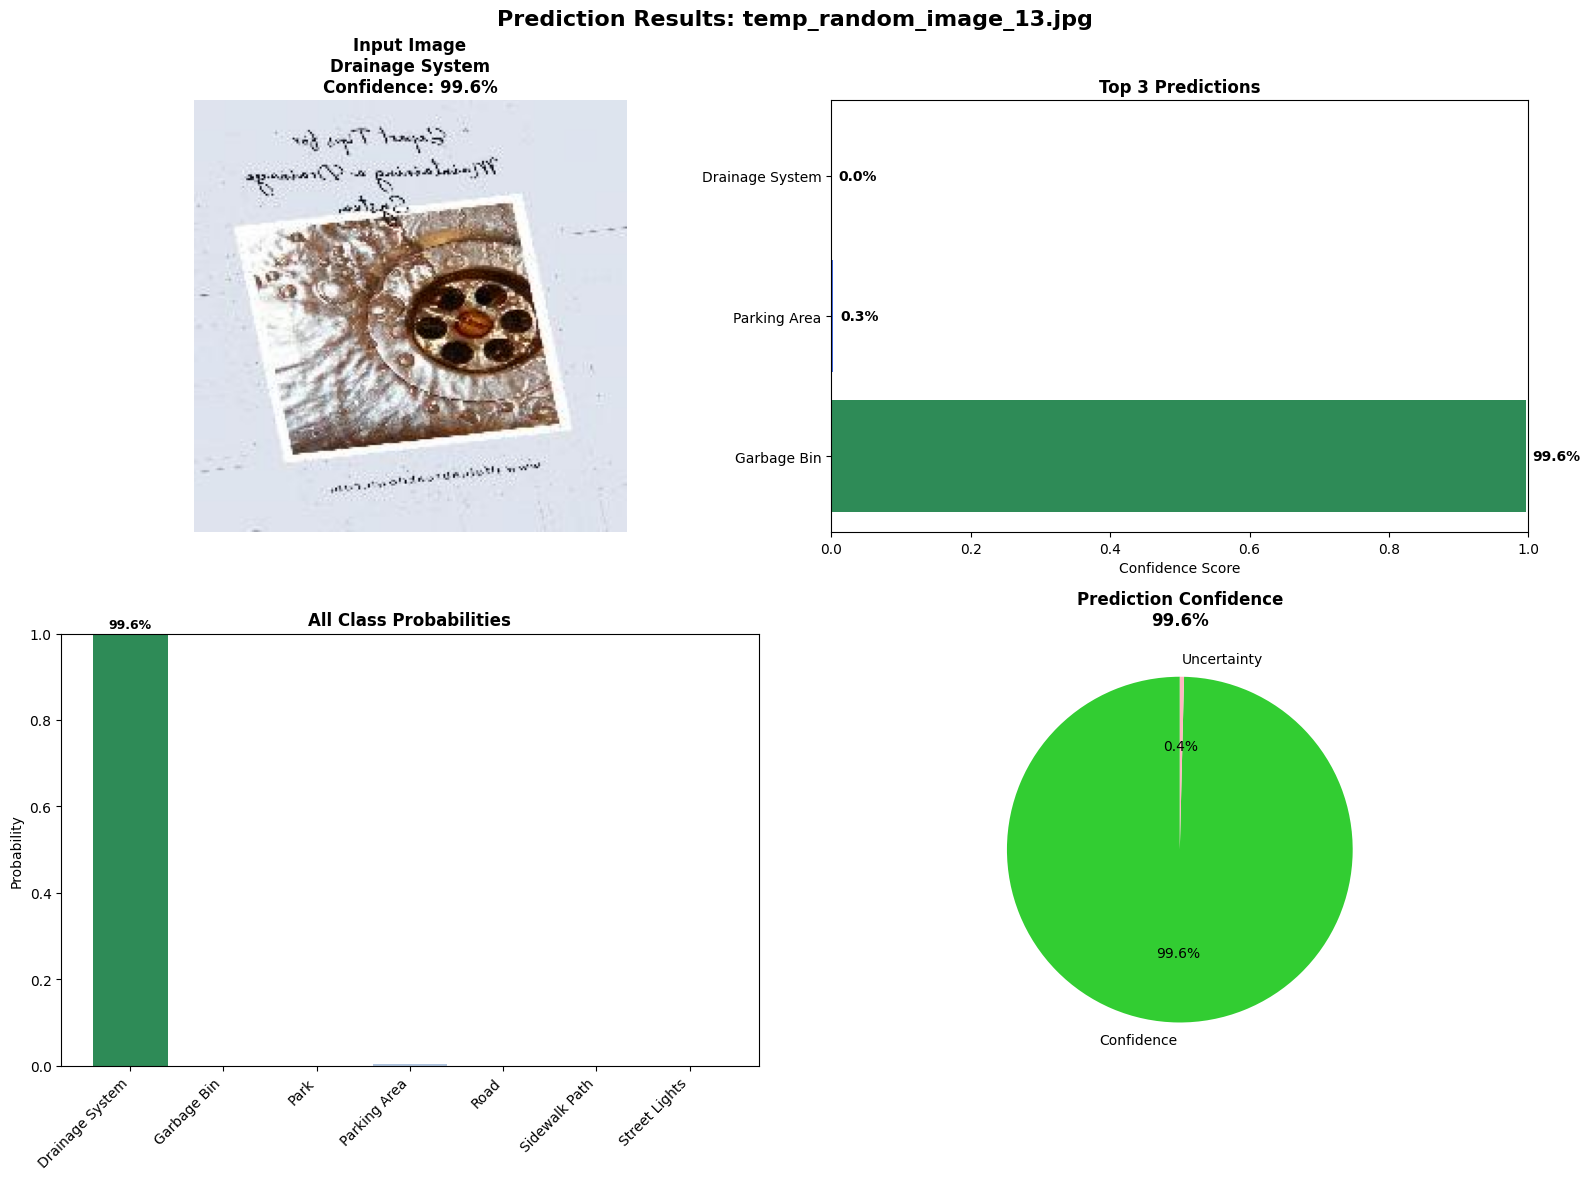

🎯 DETAILED PREDICTION RESULTS
📷 Image: temp_random_image_13.jpg
🏆 Predicted Class: Drainage System
📊 Confidence: 99.61%
🎯 Certainty Level: Very High

🥇 Top 3 Predictions:
  1. Drainage System: 99.61%
  2. Parking Area: 0.31%
  3. Garbage Bin: 0.04%

🎯 Random Test #2
True Label: Drainage System
🔍 Analyzing image: temp_random_image_21.jpg


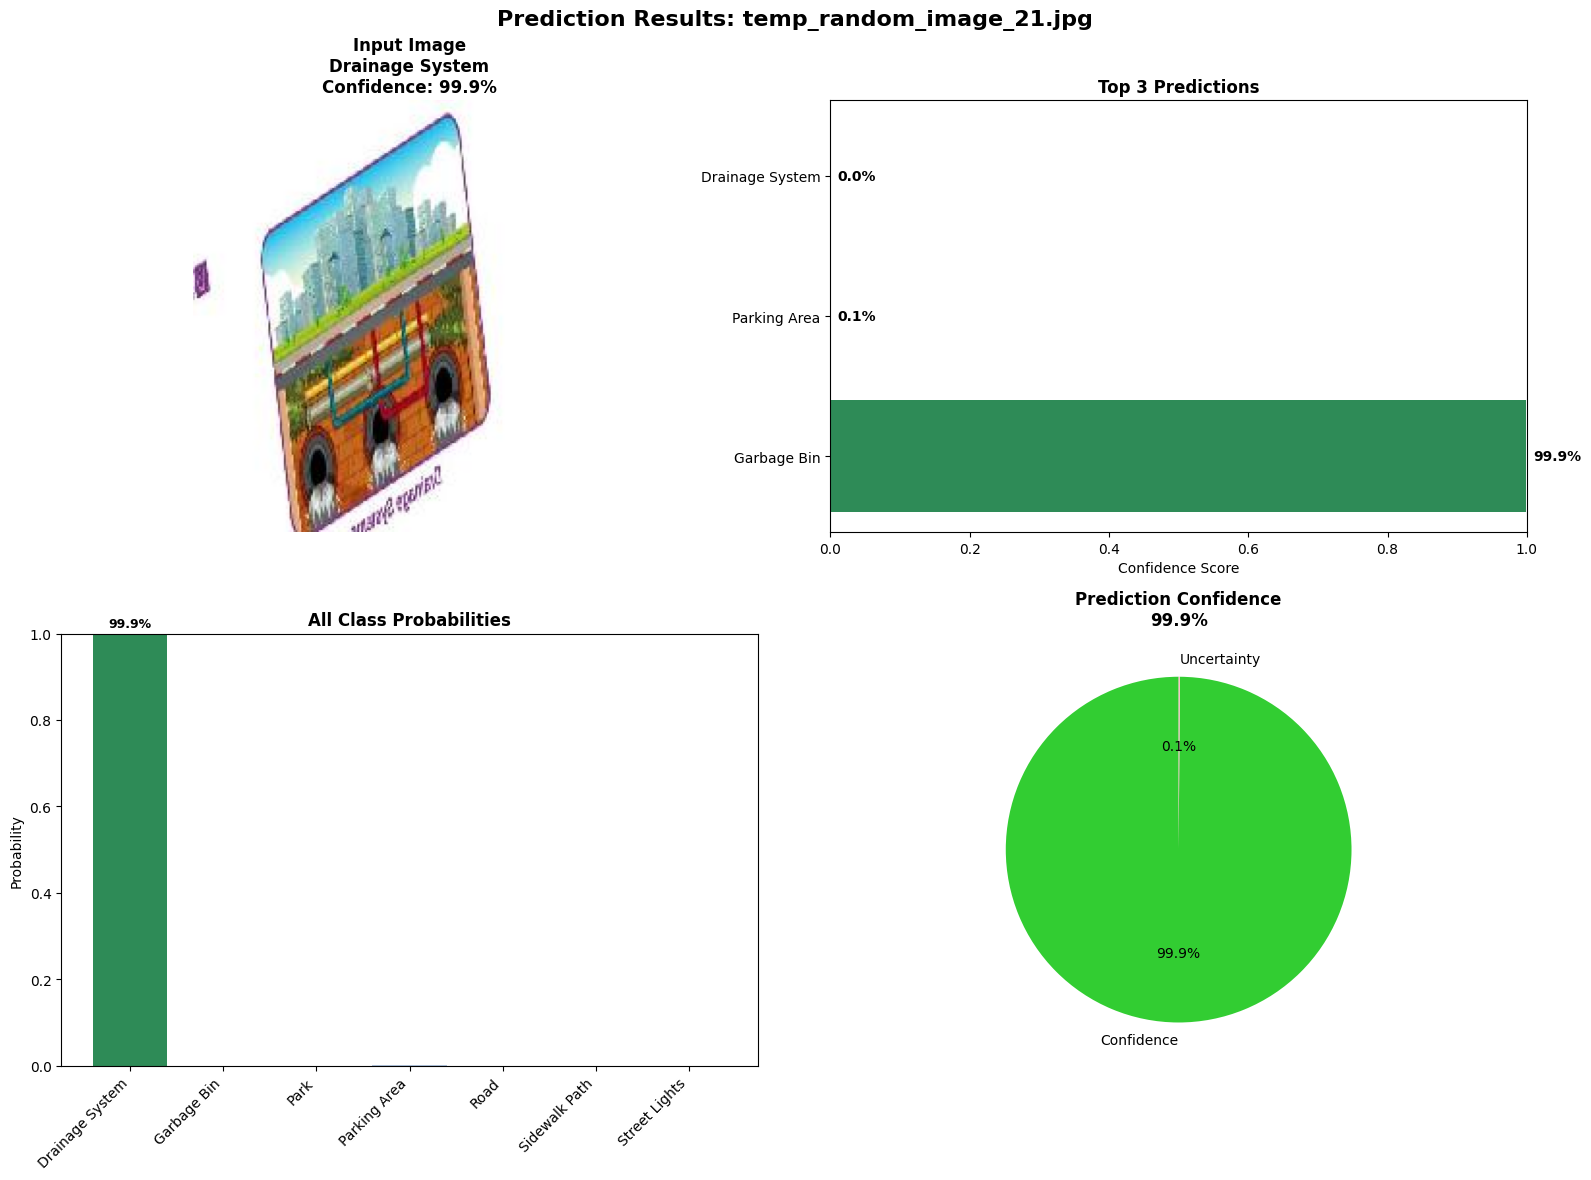

🎯 DETAILED PREDICTION RESULTS
📷 Image: temp_random_image_21.jpg
🏆 Predicted Class: Drainage System
📊 Confidence: 99.89%
🎯 Certainty Level: Very High

🥇 Top 3 Predictions:
  1. Drainage System: 99.89%
  2. Parking Area: 0.07%
  3. Garbage Bin: 0.04%

🎯 Random Test #3
True Label: Drainage System
🔍 Analyzing image: temp_random_image_26.jpg


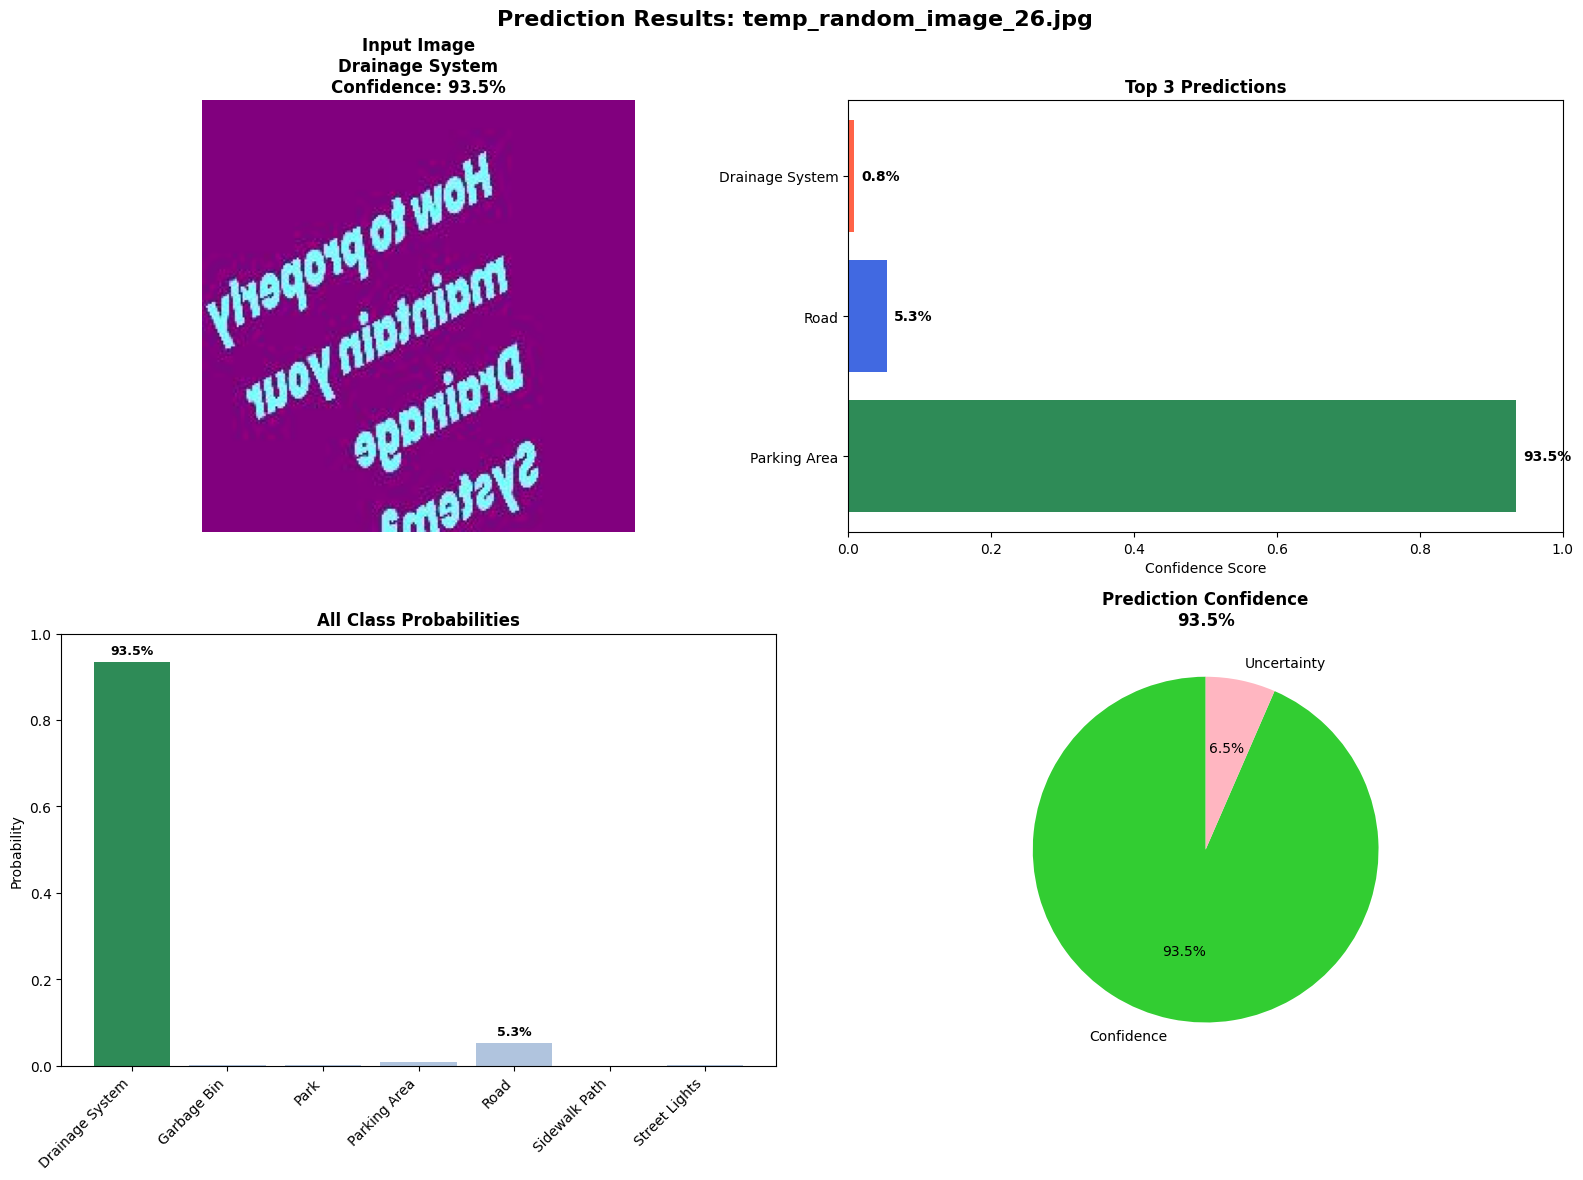

🎯 DETAILED PREDICTION RESULTS
📷 Image: temp_random_image_26.jpg
🏆 Predicted Class: Drainage System
📊 Confidence: 93.47%
🎯 Certainty Level: Very High

🥇 Top 3 Predictions:
  1. Drainage System: 93.47%
  2. Road: 5.34%
  3. Parking Area: 0.85%

🎯 Random Test Summary:
  ✅ Correct Predictions: 3/3
  📊 Accuracy: 100.0%

📱 Test 3: TFLite model testing...
⚖️ Comparing H5 vs TFLite predictions for: test_sample_image.jpg
🔍 H5 Model prediction...


🔍 Analyzing image: test_sample_image.jpg
  🎯 H5 Prediction: drainage_system (99.7%)
📱 TFLite Model prediction...
📱 Loading TFLite model: civic_classifier.tflite
✅ TFLite model loaded successfully
📊 Input shape: [  1 224 224   3]
🔢 Quantized: No
  🎯 TFLite Prediction: drainage_system (31.1%)
📱 Quantized TFLite Model prediction...
📱 Loading TFLite model: civic_classifier_quantized.tflite
✅ TFLite model loaded successfully
📊 Input shape: [  1 224 224   3]
🔢 Quantized: Yes
  🎯 Quantized Prediction: drainage_system (99.2%)

📊 Model Comparison Summary:
✅ All models agree on the prediction!


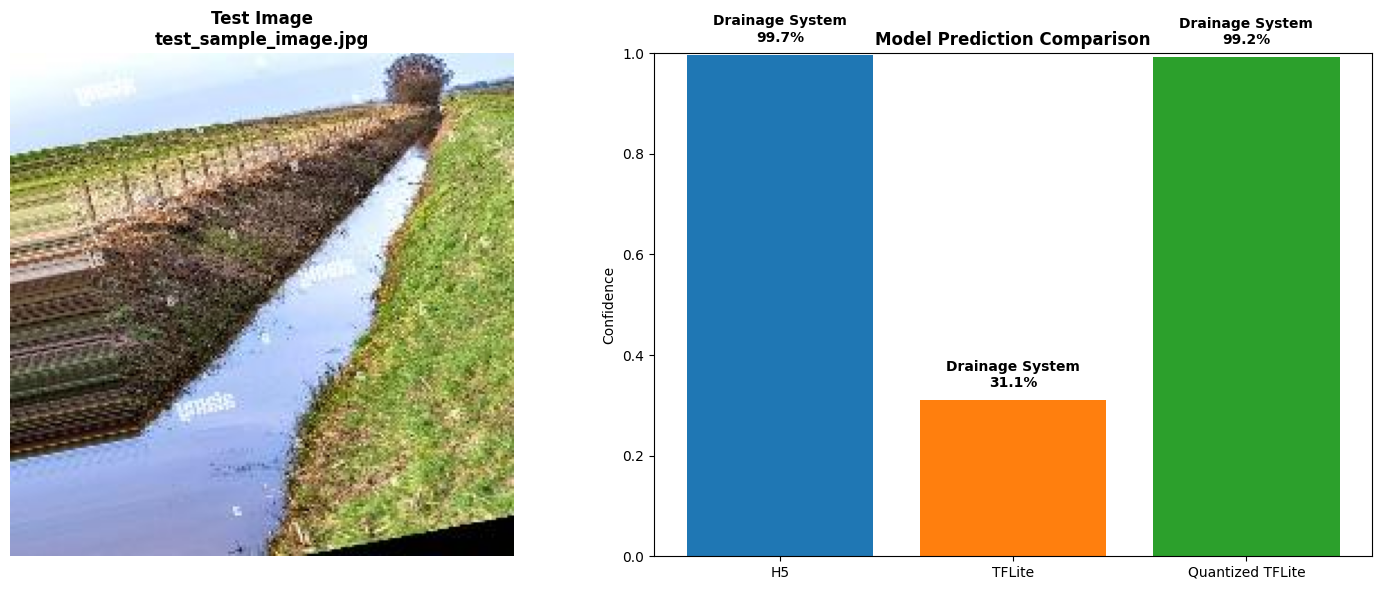


✅ Complete test suite finished!

📋 MODEL CAPABILITIES SUMMARY
🔹 H5 Model: 13.29 MB
🔹 TFLite Model: 4.53 MB
🔹 Quantized TFLite: 1.37 MB

🎯 Classification Classes (7):
  1. Drainage System
  2. Garbage Bin
  3. Park
  4. Parking Area
  5. Road
  6. Sidewalk Path
  7. Street Lights

📊 Model Specifications:
  🖼️ Input Size: (224, 224)
  📦 Batch Size: 32
  🏗️ Architecture: EfficientNetB0 + Custom Head
  🎯 Transfer Learning: Yes (ImageNet weights)

🔧 Available Functions:
  • predict_single_image(model, 'image_path')
  • predict_from_folder(model, 'folder_path')
  • predict_multiple_images(model, image_paths_list)
  • TFLitePredictor(tflite_model_path).predict('image_path')
  • compare_h5_vs_tflite_predictions('image_path')
📖 EXAMPLE USAGE GUIDE

# 1. BASIC PREDICTION (Single Image)
model = keras.models.load_model('civic_classifier.h5')
result = predict_single_image(model, 'path/to/your/image.jpg')

# 2. BATCH PREDICTION (Multiple Images)
image_paths = ['image1.jpg', 'image2.jpg', 'image3.jp

In [8]:
# ================================================================================
# STEP 10: MODEL EVALUATION AND CONFUSION MATRIX
# ================================================================================
print("\n📊 STEP 10: Model Evaluation and Analysis")
print("=" * 60)

import numpy as np
from sklearn.metrics import accuracy_score

def evaluate_model(model, val_generator, compute_top2=True):
    """Comprehensive model evaluation"""
    
    print("🧪 Evaluating model performance...")
    
    # Reset generator (only works if it's an ImageDataGenerator, safe to try)
    try:
        val_generator.reset()
    except AttributeError:
        pass
    
    # Get predictions
    print("🔄 Generating predictions...")
    predictions = model.predict(val_generator, verbose=1)
    
    # Handle binary vs multiclass
    if predictions.shape[1] == 1:  # Binary classification (sigmoid)
        y_pred = (predictions.ravel() > 0.5).astype(int)
    else:  # Multiclass
        y_pred = np.argmax(predictions, axis=1)
    
    # Get true labels
    y_true = val_generator.classes
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    print(f"🎯 Overall Accuracy: {accuracy:.4f}")
    
    # Calculate top-2 accuracy manually (only for multiclass)
    if compute_top2 and predictions.shape[1] > 2:
        top_2_correct = 0
        for i, true_label in enumerate(y_true):
            top_2_preds = np.argsort(predictions[i])[-2:]  # Get top 2 predictions
            if true_label in top_2_preds:
                top_2_correct += 1
        
        top_2_accuracy = top_2_correct / len(y_true)
        print(f"🥈 Top-2 Accuracy: {top_2_accuracy:.4f}")
    
    return y_true, y_pred, predictions, accuracy


def plot_confusion_matrix(y_true, y_pred):
    """Create detailed confusion matrix"""
    
    print("📈 Creating confusion matrix...")
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    # Create annotation array
    annot_array = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot_array[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
    
    # Plot heatmap
    sns.heatmap(cm, annot=annot_array, fmt='', cmap='Blues', 
                xticklabels=[name.replace('_', ' ').title() for name in config.CLASS_NAMES],
                yticklabels=[name.replace('_', ' ').title() for name in config.CLASS_NAMES],
                cbar_kws={'label': 'Number of Predictions'})
    
    plt.title('Confusion Matrix - Civic Categories Classifier', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Add overall accuracy
    overall_accuracy = np.trace(cm) / np.sum(cm)
    plt.figtext(0.02, 0.02, f'Overall Accuracy: {overall_accuracy:.4f}', 
                fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
    
    plt.tight_layout()
    plt.show()
    
    return cm

def generate_classification_report(y_true, y_pred):
    """Generate detailed classification report"""
    
    print("📋 Classification Report:")
    print("=" * 60)
    
    # Generate report
    report = classification_report(
        y_true, y_pred, 
        target_names=[name.replace('_', ' ').title() for name in config.CLASS_NAMES],
        digits=4
    )
    print(report)
    
    # Create detailed metrics DataFrame
    report_dict = classification_report(y_true, y_pred, target_names=config.CLASS_NAMES, output_dict=True)
    
    df_report = pd.DataFrame(report_dict).transpose()
    df_report = df_report.round(4)
    
    # Save report to CSV
    df_report.to_csv('classification_report.csv')
    print("💾 Classification report saved to 'classification_report.csv'")
    
    return df_report

def show_sample_predictions(model, val_generator, num_samples=12):
    """Show sample predictions with confidence scores"""
    
    print(f"👀 Showing {num_samples} sample predictions...")
    
    # Get a batch of data
    val_generator.reset()
    batch_x, batch_y = next(val_generator)
    
    # Make predictions on the batch
    predictions = model.predict(batch_x, verbose=0)
    
    # Create subplots
    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(batch_x))):
        # Get true and predicted labels
        true_label_idx = np.argmax(batch_y[i])
        pred_label_idx = np.argmax(predictions[i])
        
        true_label = config.CLASS_NAMES[true_label_idx].replace('_', ' ').title()
        pred_label = config.CLASS_NAMES[pred_label_idx].replace('_', ' ').title()
        confidence = predictions[i][pred_label_idx]
        
        # Display image
        axes[i].imshow(batch_x[i])
        
        # Color code the title (green for correct, red for incorrect)
        color = 'green' if pred_label_idx == true_label_idx else 'red'
        title = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1%}'
        
        axes[i].set_title(title, color=color, fontweight='bold', fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('Sample Predictions from Validation Set', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Execute evaluation
if dataset_valid:
    y_true, y_pred, predictions, accuracy = evaluate_model(fine_tuned_model, val_generator)
    cm = plot_confusion_matrix(y_true, y_pred)
    report_df = generate_classification_report(y_true, y_pred)
    show_sample_predictions(fine_tuned_model, val_generator)

# ================================================================================
# STEP 11: SAVE MODEL IN MULTIPLE FORMATS (H5 AND TFLITE)
# ================================================================================
print("\n💾 STEP 11: Saving Model in Multiple Formats")
print("=" * 60)

def save_h5_model(model):
    """Save model in H5 format"""
    
    print("💾 Saving model in H5 format...")
    
    model.save(config.MODEL_H5)
    print(f"✅ Model saved as '{config.MODEL_H5}'")
    
    # Get model size
    model_size = os.path.getsize(config.MODEL_H5) / (1024 * 1024)  # Convert to MB
    print(f"📊 Model size: {model_size:.2f} MB")

def convert_to_tflite(model, quantized=False):
    """Convert model to TensorFlow Lite format"""
    
    print(f"🔄 Converting to TensorFlow Lite {'(Quantized)' if quantized else ''}...")
    
    # Create converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    if quantized:
        # Enable quantization for smaller model size
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        
        # Create representative dataset for quantization
        def representative_dataset():
            # Get some validation data for quantization
            val_generator.reset()
            batch_x, _ = next(val_generator)
            for i in range(min(10, len(batch_x))):  # Use 10 samples
                yield [batch_x[i:i+1].astype(np.float32)]
        
        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8
        
        output_file = config.MODEL_QUANTIZED_TFLITE
    else:
        output_file = config.MODEL_TFLITE
    
    # Convert model
    try:
        tflite_model = converter.convert()
        
        # Save the model
        with open(output_file, 'wb') as f:
            f.write(tflite_model)
        
        # Get model size
        model_size = os.path.getsize(output_file) / (1024 * 1024)  # Convert to MB
        
        print(f"✅ TensorFlow Lite model saved as '{output_file}'")
        print(f"📊 Model size: {model_size:.2f} MB")
        
        return output_file, model_size
        
    except Exception as e:
        print(f"❌ Error converting to TensorFlow Lite: {e}")
        return None, 0

def test_tflite_model(tflite_model_path):
    """Test TensorFlow Lite model"""
    
    print(f"🧪 Testing TensorFlow Lite model: {tflite_model_path}")
    
    try:
        # Load TFLite model
        interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
        interpreter.allocate_tensors()
        
        # Get input and output details
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        
        print("📊 TFLite Model Details:")
        print(f"  Input shape: {input_details[0]['shape']}")
        print(f"  Output shape: {output_details[0]['shape']}")
        print(f"  Input dtype: {input_details[0]['dtype']}")
        print(f"  Output dtype: {output_details[0]['dtype']}")
        
        # Test with a sample image
        val_generator.reset()
        batch_x, batch_y = next(val_generator)
        test_image = batch_x[0:1]  # Take first image
        
        # Prepare input based on model type
        if input_details[0]['dtype'] == np.uint8:
            # Quantized model expects uint8 input
            test_image_processed = (test_image * 255).astype(np.uint8)
        else:
            # Float model expects float32 input
            test_image_processed = test_image.astype(np.float32)
        
        # Run inference
        interpreter.set_tensor(input_details[0]['index'], test_image_processed)
        interpreter.invoke()
        
        # Get prediction
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        if output_details[0]['dtype'] == np.uint8:
            # Dequantize output for quantized models
            scale, zero_point = output_details[0]['quantization']
            output_data = (output_data.astype(np.float32) - zero_point) * scale
        
        predicted_class_idx = np.argmax(output_data[0])
        predicted_class = config.CLASS_NAMES[predicted_class_idx]
        confidence = output_data[0][predicted_class_idx]
        
        print(f"🎯 Test prediction: {predicted_class}")
        print(f"📊 Confidence: {confidence:.4f}")
        print("✅ TensorFlow Lite model is working correctly!")
        
        return True
        
    except Exception as e:
        print(f"❌ Error testing TFLite model: {e}")
        return False

def compare_model_sizes():
    """Compare sizes of different model formats"""
    
    print("\n📊 Model Size Comparison:")
    print("=" * 40)
    
    models_info = []
    
    # H5 model
    if os.path.exists(config.MODEL_H5):
        h5_size = os.path.getsize(config.MODEL_H5) / (1024 * 1024)
        models_info.append(("H5 Model", config.MODEL_H5, h5_size))
        print(f"🔹 H5 Model: {h5_size:.2f} MB")
    
    # TFLite model
    if os.path.exists(config.MODEL_TFLITE):
        tflite_size = os.path.getsize(config.MODEL_TFLITE) / (1024 * 1024)
        models_info.append(("TFLite Model", config.MODEL_TFLITE, tflite_size))
        print(f"🔹 TFLite Model: {tflite_size:.2f} MB")
    
    # Quantized TFLite model
    if os.path.exists(config.MODEL_QUANTIZED_TFLITE):
        quantized_size = os.path.getsize(config.MODEL_QUANTIZED_TFLITE) / (1024 * 1024)
        models_info.append(("Quantized TFLite", config.MODEL_QUANTIZED_TFLITE, quantized_size))
        print(f"🔹 Quantized TFLite: {quantized_size:.2f} MB")
    
    # Create comparison chart
    if len(models_info) > 1:
        names = [info[0] for info in models_info]
        sizes = [info[2] for info in models_info]
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(names, sizes, color=['#1f77b4', '#ff7f0e', '#2ca02c'][:len(names)])
        plt.title('Model Size Comparison', fontweight='bold', fontsize=14)
        plt.ylabel('Size (MB)')
        plt.xticks(rotation=45)
        
        # Add value labels on bars
        for bar, size in zip(bars, sizes):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sizes)*0.01,
                    f'{size:.2f} MB', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

# Execute model saving
if dataset_valid:
    # Save H5 model
    save_h5_model(fine_tuned_model)
    
    # Convert to TFLite (normal)
    tflite_path, tflite_size = convert_to_tflite(fine_tuned_model, quantized=False)
    
    # Convert to quantized TFLite
    quantized_tflite_path, quantized_size = convert_to_tflite(fine_tuned_model, quantized=True)
    
    # Test TFLite models
    if tflite_path:
        test_tflite_model(tflite_path)
    
    if quantized_tflite_path:
        test_tflite_model(quantized_tflite_path)
    
    # Compare model sizes
    compare_model_sizes()

# ================================================================================
# STEP 12: CUSTOM IMAGE PREDICTION FUNCTIONS
# ================================================================================
print("\n🔍 STEP 12: Custom Image Prediction Functions")
print("=" * 60)

def load_and_preprocess_image(image_path):
    """Load and preprocess a single image for prediction"""
    
    try:
        # Load image
        img = load_img(image_path, target_size=config.IMG_SIZE)
        
        # Convert to array and normalize
        img_array = img_to_array(img)
        img_array = img_array / 255.0
        
        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)
        
        return img_array, img
        
    except Exception as e:
        print(f"❌ Error loading image {image_path}: {e}")
        return None, None

def predict_single_image(model, image_path, show_visualization=True):
    """Predict class for a single custom image"""
    
    print(f"🔍 Analyzing image: {os.path.basename(image_path)}")
    
    # Load and preprocess image
    img_array, original_img = load_and_preprocess_image(image_path)
    
    if img_array is None:
        return None
    
    # Make prediction
    predictions = model.predict(img_array, verbose=0)
    
    # Get results
    pred_probs = predictions[0]
    predicted_class_idx = np.argmax(pred_probs)
    predicted_class = config.CLASS_NAMES[predicted_class_idx]
    confidence = pred_probs[predicted_class_idx]
    
    # Get top 3 predictions
    top_3_idx = np.argsort(pred_probs)[-3:][::-1]
    top_3_predictions = [(config.CLASS_NAMES[idx], pred_probs[idx]) for idx in top_3_idx]
    
    # Create results dictionary
    results = {
        'image_path': image_path,
        'predicted_class': predicted_class,
        'confidence': confidence,
        'top_3_predictions': top_3_predictions,
        'all_probabilities': {config.CLASS_NAMES[i]: pred_probs[i] for i in range(config.NUM_CLASSES)}
    }
    
    if show_visualization:
        # Create comprehensive visualization
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Prediction Results: {os.path.basename(image_path)}', 
                     fontsize=16, fontweight='bold')
        
        # Show original image
        axes[0, 0].imshow(original_img)
        axes[0, 0].set_title(f'Input Image\n{predicted_class.replace("_", " ").title()}\nConfidence: {confidence:.1%}', 
                            fontweight='bold')
        axes[0, 0].axis('off')
        
        # Top 3 predictions
        top_3_classes = [pred[0].replace('_', ' ').title() for pred in top_3_predictions]
        top_3_probs = [pred[1] for pred in top_3_predictions]
        
        colors = ['#2E8B57', '#4169E1', '#FF6347']
        bars = axes[0, 1].barh(range(3), top_3_probs, color=colors)
        axes[0, 1].set_yticks(range(3))
        axes[0, 1].set_yticklabels(reversed(top_3_classes))
        axes[0, 1].set_xlabel('Confidence Score')
        axes[0, 1].set_title('Top 3 Predictions', fontweight='bold')
        axes[0, 1].set_xlim(0, 1)
        
        # Add percentage labels
        for i, (bar, prob) in enumerate(zip(bars, top_3_probs)):
            axes[0, 1].text(prob + 0.01, bar.get_y() + bar.get_height()/2,
                           f'{prob:.1%}', va='center', fontweight='bold')
        
        # All class probabilities
        all_classes = [name.replace('_', ' ').title() for name in config.CLASS_NAMES]
        all_probs = [pred_probs[i] for i in range(config.NUM_CLASSES)]
        
        colors_all = ['#2E8B57' if i == predicted_class_idx else '#B0C4DE' for i in range(config.NUM_CLASSES)]
        bars = axes[1, 0].bar(range(config.NUM_CLASSES), all_probs, color=colors_all)
        axes[1, 0].set_xticks(range(config.NUM_CLASSES))
        axes[1, 0].set_xticklabels(all_classes, rotation=45, ha='right')
        axes[1, 0].set_ylabel('Probability')
        axes[1, 0].set_title('All Class Probabilities', fontweight='bold')
        axes[1, 0].set_ylim(0, 1)
        
        # Add probability labels for significant values
        for i, (bar, prob) in enumerate(zip(bars, all_probs)):
            if prob > 0.05:  # Only show for probabilities > 5%
                axes[1, 0].text(bar.get_x() + bar.get_width()/2, 
                               bar.get_height() + 0.01,
                               f'{prob:.1%}', ha='center', va='bottom', 
                               fontweight='bold', fontsize=9)
        
        # Prediction confidence gauge
        axes[1, 1].pie([confidence, 1-confidence], 
                      labels=['Confidence', 'Uncertainty'],
                      colors=['#32CD32', '#FFB6C1'],
                      autopct='%1.1f%%',
                      startangle=90)
        axes[1, 1].set_title(f'Prediction Confidence\n{confidence:.1%}', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed results
        print("🎯 DETAILED PREDICTION RESULTS")
        print("=" * 50)
        print(f"📷 Image: {os.path.basename(image_path)}")
        print(f"🏆 Predicted Class: {predicted_class.replace('_', ' ').title()}")
        print(f"📊 Confidence: {confidence:.2%}")
        print(f"🎯 Certainty Level: {'Very High' if confidence > 0.9 else 'High' if confidence > 0.7 else 'Medium' if confidence > 0.5 else 'Low'}")
        
        print("\n🥇 Top 3 Predictions:")
        for i, (class_name, prob) in enumerate(top_3_predictions):
            print(f"  {i+1}. {class_name.replace('_', ' ').title()}: {prob:.2%}")
    
    return results

def predict_multiple_images(model, image_paths, save_results=True):
    """Predict multiple images and save results"""
    
    print(f"🔍 Predicting {len(image_paths)} images...")
    
    all_results = []
    
    for i, image_path in enumerate(image_paths):
        print(f"Processing {i+1}/{len(image_paths)}: {os.path.basename(image_path)}")
        
        result = predict_single_image(model, image_path, show_visualization=False)
        if result:
            all_results.append(result)
    
    if save_results and all_results:
        # Create DataFrame with results
        df_data = []
        for result in all_results:
            row = {
                'image_name': os.path.basename(result['image_path']),
                'image_path': result['image_path'],
                'predicted_class': result['predicted_class'],
                'confidence': result['confidence'],
                'top_1': result['top_3_predictions'][0][0],
                'top_1_confidence': result['top_3_predictions'][0][1],
                'top_2': result['top_3_predictions'][1][0],
                'top_2_confidence': result['top_3_predictions'][1][1],
                'top_3': result['top_3_predictions'][2][0],
                'top_3_confidence': result['top_3_predictions'][2][1]
            }
            df_data.append(row)
        
        df = pd.DataFrame(df_data)
        csv_filename = f'predictions_results_{len(all_results)}_images.csv'
        df.to_csv(csv_filename, index=False)
        
        print(f"💾 Results saved to '{csv_filename}'")
        
        # Show prediction summary
        print("\n📊 Prediction Summary:")
        class_counts = df['predicted_class'].value_counts()
        for class_name, count in class_counts.items():
            percentage = (count / len(df)) * 100
            print(f"  🔹 {class_name.replace('_', ' ').title()}: {count} images ({percentage:.1f}%)")
    
    return all_results

def predict_from_folder(model, folder_path):
    """Predict all images in a folder"""
    
    print(f"📁 Scanning folder: {folder_path}")
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {folder_path}")
        return []
    
    # Find all image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.webp']
    image_paths = []
    
    for ext in image_extensions:
        pattern = os.path.join(folder_path, ext)
        image_paths.extend(glob.glob(pattern))
        pattern = os.path.join(folder_path, ext.upper())
        image_paths.extend(glob.glob(pattern))
    
    if not image_paths:
        print("❌ No image files found in the folder!")
        return []
    
    print(f"📸 Found {len(image_paths)} images")
    
    # Predict all images
    results = predict_multiple_images(model, image_paths, save_results=True)
    
    return results

def test_random_images(model, num_random=5):
    """Test model on random images from validation set"""
    
    print(f"🎲 Testing {num_random} random images from validation set...")
    
    # Get random validation images
    val_generator.reset()
    batch_x, batch_y = next(val_generator)
    
    # Select random indices
    random_indices = random.sample(range(len(batch_x)), min(num_random, len(batch_x)))
    
    results = []
    
    for idx in random_indices:
        # Create temporary image file
        temp_image = batch_x[idx]
        temp_path = f"temp_random_image_{idx}.jpg"
        
        # Save temporary image
        img_pil = Image.fromarray((temp_image * 255).astype(np.uint8))
        img_pil.save(temp_path)
        
        # Get true label
        true_label_idx = np.argmax(batch_y[idx])
        true_label = config.CLASS_NAMES[true_label_idx]
        
        print(f"\n🎯 Random Test #{len(results)+1}")
        print(f"True Label: {true_label.replace('_', ' ').title()}")
        
        # Predict
        result = predict_single_image(model, temp_path, show_visualization=True)
        
        if result:
            result['true_label'] = true_label
            result['correct'] = result['predicted_class'] == true_label
            results.append(result)
        
        # Clean up temporary file
        if os.path.exists(temp_path):
            os.remove(temp_path)
    
    # Show accuracy summary
    if results:
        correct_predictions = sum([r['correct'] for r in results])
        accuracy = correct_predictions / len(results)
        
        print(f"\n🎯 Random Test Summary:")
        print(f"  ✅ Correct Predictions: {correct_predictions}/{len(results)}")
        print(f"  📊 Accuracy: {accuracy:.1%}")
    
    return results

# ================================================================================
# STEP 13: TFLITE PREDICTION FUNCTIONS
# ================================================================================
print("\n📱 STEP 13: TensorFlow Lite Prediction Functions")
print("=" * 60)

class TFLitePredictor:
    """TensorFlow Lite model predictor class"""
    
    def __init__(self, model_path):
        """Initialize TFLite predictor"""
        self.model_path = model_path
        self.interpreter = None
        self.input_details = None
        self.output_details = None
        self.is_quantized = False
        
        self.load_model()
    
    def load_model(self):
        """Load TensorFlow Lite model"""
        try:
            print(f"📱 Loading TFLite model: {os.path.basename(self.model_path)}")
            
            self.interpreter = tf.lite.Interpreter(model_path=self.model_path)
            self.interpreter.allocate_tensors()
            
            self.input_details = self.interpreter.get_input_details()
            self.output_details = self.interpreter.get_output_details()
            
            # Check if model is quantized
            self.is_quantized = self.input_details[0]['dtype'] == np.uint8
            
            print(f"✅ TFLite model loaded successfully")
            print(f"📊 Input shape: {self.input_details[0]['shape']}")
            print(f"🔢 Quantized: {'Yes' if self.is_quantized else 'No'}")
            
        except Exception as e:
            print(f"❌ Error loading TFLite model: {e}")
            self.interpreter = None
    
    def predict(self, image_path):
        """Make prediction using TFLite model"""
        
        if self.interpreter is None:
            print("❌ Model not loaded!")
            return None
        
        # Load and preprocess image
        img_array, _ = load_and_preprocess_image(image_path)
        
        if img_array is None:
            return None
        
        # Prepare input based on model type
        if self.is_quantized:
            # Quantized model expects uint8 input (0-255)
            input_data = (img_array * 255).astype(np.uint8)
        else:
            # Float model expects float32 input (0-1)
            input_data = img_array.astype(np.float32)
        
        # Run inference
        self.interpreter.set_tensor(self.input_details[0]['index'], input_data)
        self.interpreter.invoke()
        
        # Get output
        output_data = self.interpreter.get_tensor(self.output_details[0]['index'])
        
        # Dequantize output if quantized model
        if self.is_quantized:
            scale, zero_point = self.output_details[0]['quantization']
            if scale != 0:  # Avoid division by zero
                output_data = (output_data.astype(np.float32) - zero_point) * scale
        
        # Process predictions
        pred_probs = output_data[0]
        
        # Apply softmax if needed (some models might not have it in the last layer)
        if not self.is_quantized:
            pred_probs = tf.nn.softmax(pred_probs).numpy()
        
        predicted_class_idx = np.argmax(pred_probs)
        predicted_class = config.CLASS_NAMES[predicted_class_idx]
        confidence = pred_probs[predicted_class_idx]
        
        # Get top 3 predictions
        top_3_idx = np.argsort(pred_probs)[-3:][::-1]
        top_3_predictions = [(config.CLASS_NAMES[idx], pred_probs[idx]) for idx in top_3_idx]
        
        return {
            'predicted_class': predicted_class,
            'confidence': float(confidence),
            'top_3_predictions': top_3_predictions,
            'model_type': 'TFLite (Quantized)' if self.is_quantized else 'TFLite (Float)'
        }

def compare_h5_vs_tflite_predictions(image_path):
    """Compare predictions between H5 and TFLite models"""
    
    print(f"⚖️ Comparing H5 vs TFLite predictions for: {os.path.basename(image_path)}")
    print("=" * 60)
    
    results = {}
    
    # H5 model prediction
    if os.path.exists(config.MODEL_H5):
        print("🔍 H5 Model prediction...")
        h5_model = keras.models.load_model(config.MODEL_H5)
        h5_result = predict_single_image(h5_model, image_path, show_visualization=False)
        if h5_result:
            results['H5'] = h5_result
            print(f"  🎯 H5 Prediction: {h5_result['predicted_class']} ({h5_result['confidence']:.1%})")
    
    # TFLite model prediction
    if os.path.exists(config.MODEL_TFLITE):
        print("📱 TFLite Model prediction...")
        tflite_predictor = TFLitePredictor(config.MODEL_TFLITE)
        tflite_result = tflite_predictor.predict(image_path)
        if tflite_result:
            results['TFLite'] = tflite_result
            print(f"  🎯 TFLite Prediction: {tflite_result['predicted_class']} ({tflite_result['confidence']:.1%})")
    
    # Quantized TFLite model prediction
    if os.path.exists(config.MODEL_QUANTIZED_TFLITE):
        print("📱 Quantized TFLite Model prediction...")
        quantized_predictor = TFLitePredictor(config.MODEL_QUANTIZED_TFLITE)
        quantized_result = quantized_predictor.predict(image_path)
        if quantized_result:
            results['Quantized TFLite'] = quantized_result
            print(f"  🎯 Quantized Prediction: {quantized_result['predicted_class']} ({quantized_result['confidence']:.1%})")
    
    # Compare results
    if len(results) > 1:
        print("\n📊 Model Comparison Summary:")
        
        # Check if all models agree
        predictions = [result['predicted_class'] for result in results.values()]
        all_agree = len(set(predictions)) == 1
        
        if all_agree:
            print("✅ All models agree on the prediction!")
        else:
            print("⚠️ Models have different predictions!")
        
        # Create comparison visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Load and show image
        img_array, original_img = load_and_preprocess_image(image_path)
        axes[0].imshow(original_img)
        axes[0].set_title(f'Test Image\n{os.path.basename(image_path)}', fontweight='bold')
        axes[0].axis('off')
        
        # Compare predictions
        model_names = list(results.keys())
        confidences = [results[name]['confidence'] for name in model_names]
        predicted_classes = [results[name]['predicted_class'].replace('_', ' ').title() for name in model_names]
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c'][:len(model_names)]
        bars = axes[1].bar(model_names, confidences, color=colors)
        axes[1].set_ylabel('Confidence')
        axes[1].set_title('Model Prediction Comparison', fontweight='bold')
        axes[1].set_ylim(0, 1)
        
        # Add prediction labels on bars
        for bar, conf, pred_class in zip(bars, confidences, predicted_classes):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{pred_class}\n{conf:.1%}', ha='center', va='bottom', 
                        fontweight='bold', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return results

# ================================================================================
# STEP 14: COMPLETE USAGE EXAMPLES AND TESTING
# ================================================================================
print("\n🎮 STEP 14: Complete Usage Examples and Testing")
print("=" * 60)

def run_complete_test_suite():
    """Run a complete test suite to demonstrate all functionality"""
    
    print("🧪 RUNNING COMPLETE TEST SUITE")
    print("=" * 60)
    
    if not dataset_valid:
        print("❌ Dataset validation failed. Cannot run tests.")
        return
    
    # Test 1: Load saved models
    print("\n📂 Test 1: Loading saved models...")
    
    h5_model = None
    if os.path.exists(config.MODEL_H5):
        try:
            h5_model = keras.models.load_model(config.MODEL_H5)
            print("✅ H5 model loaded successfully")
        except Exception as e:
            print(f"❌ Error loading H5 model: {e}")
    
    # Test 2: Random validation images
    if h5_model:
        print("\n🎲 Test 2: Random validation images...")
        random_results = test_random_images(h5_model, num_random=3)
    
    # Test 3: TFLite model testing
    print("\n📱 Test 3: TFLite model testing...")
    
    if os.path.exists(config.MODEL_TFLITE) or os.path.exists(config.MODEL_QUANTIZED_TFLITE):
        # Get a sample image from validation set
        val_generator.reset()
        batch_x, batch_y = next(val_generator)
        
        # Save first image as test sample
        test_img = batch_x[0]
        test_path = "test_sample_image.jpg"
        img_pil = Image.fromarray((test_img * 255).astype(np.uint8))
        img_pil.save(test_path)
        
        # Compare H5 vs TFLite predictions
        comparison_results = compare_h5_vs_tflite_predictions(test_path)
        
        # Clean up
        if os.path.exists(test_path):
            os.remove(test_path)
    
    print("\n✅ Complete test suite finished!")

def create_prediction_summary():
    """Create a comprehensive summary of model capabilities"""
    
    print("\n📋 MODEL CAPABILITIES SUMMARY")
    print("=" * 60)
    
    # Model information
    if os.path.exists(config.MODEL_H5):
        h5_size = os.path.getsize(config.MODEL_H5) / (1024 * 1024)
        print(f"🔹 H5 Model: {h5_size:.2f} MB")
    
    if os.path.exists(config.MODEL_TFLITE):
        tflite_size = os.path.getsize(config.MODEL_TFLITE) / (1024 * 1024)
        print(f"🔹 TFLite Model: {tflite_size:.2f} MB")
    
    if os.path.exists(config.MODEL_QUANTIZED_TFLITE):
        quantized_size = os.path.getsize(config.MODEL_QUANTIZED_TFLITE) / (1024 * 1024)
        print(f"🔹 Quantized TFLite: {quantized_size:.2f} MB")
    
    print(f"\n🎯 Classification Classes ({config.NUM_CLASSES}):")
    for i, class_name in enumerate(config.CLASS_NAMES):
        print(f"  {i+1}. {class_name.replace('_', ' ').title()}")
    
    print(f"\n📊 Model Specifications:")
    print(f"  🖼️ Input Size: {config.IMG_SIZE}")
    print(f"  📦 Batch Size: {config.BATCH_SIZE}")
    print(f"  🏗️ Architecture: EfficientNetB0 + Custom Head")
    print(f"  🎯 Transfer Learning: Yes (ImageNet weights)")
    
    print(f"\n🔧 Available Functions:")
    print(f"  • predict_single_image(model, 'image_path')")
    print(f"  • predict_from_folder(model, 'folder_path')")
    print(f"  • predict_multiple_images(model, image_paths_list)")
    print(f"  • TFLitePredictor(tflite_model_path).predict('image_path')")
    print(f"  • compare_h5_vs_tflite_predictions('image_path')")

# ================================================================================
# STEP 15: FINAL EXAMPLE USAGE
# ================================================================================
print("\n🏁 STEP 15: Final Usage Examples")
print("=" * 60)

def example_usage():
    """Show example usage of all functions"""
    
    print("📖 EXAMPLE USAGE GUIDE")
    print("=" * 50)
    
    print("""
# 1. BASIC PREDICTION (Single Image)
model = keras.models.load_model('civic_classifier.h5')
result = predict_single_image(model, 'path/to/your/image.jpg')

# 2. BATCH PREDICTION (Multiple Images)
image_paths = ['image1.jpg', 'image2.jpg', 'image3.jpg']
results = predict_multiple_images(model, image_paths)

# 3. FOLDER PREDICTION (All images in folder)
results = predict_from_folder(model, 'path/to/your/folder')

# 4. TFLITE PREDICTION
tflite_predictor = TFLitePredictor('civic_classifier.tflite')
result = tflite_predictor.predict('path/to/your/image.jpg')

# 5. QUANTIZED TFLITE PREDICTION (Smaller model)
quantized_predictor = TFLitePredictor('civic_classifier_quantized.tflite')
result = quantized_predictor.predict('path/to/your/image.jpg')

# 6. COMPARE DIFFERENT MODEL FORMATS
comparison = compare_h5_vs_tflite_predictions('path/to/your/image.jpg')

# 7. TEST RANDOM IMAGES FROM VALIDATION
random_results = test_random_images(model, num_random=5)
    """)

# Execute final demonstrations
if dataset_valid:
    # Run complete test suite
    run_complete_test_suite()
    
    # Create summary
    create_prediction_summary()
    
    # Show example usage
    example_usage()

# ================================================================================
# COMPLETION MESSAGE
# ================================================================================
print("\n🎉 CIVIC CATEGORIES CLASSIFIER - COMPLETE!")
print("=" * 60)

completion_message = f"""
✅ TRAINING AND SETUP COMPLETED SUCCESSFULLY!

📊 WHAT YOU HAVE NOW:
  🔹 Trained deep learning model with {config.NUM_CLASSES} civic categories
  🔹 H5 model file: '{config.MODEL_H5}'
  🔹 TensorFlow Lite model: '{config.MODEL_TFLITE}'
  🔹 Quantized TFLite model: '{config.MODEL_QUANTIZED_TFLITE}'
  🔹 Comprehensive evaluation reports and visualizations
  🔹 Ready-to-use prediction functions

🎯 SUPPORTED CLASSES:
{', '.join([cls.replace('_', ' ').title() for cls in config.CLASS_NAMES])}

🚀 QUICK START EXAMPLES:
  
  # Load and use H5 model
  model = keras.models.load_model('{config.MODEL_H5}')
  result = predict_single_image(model, 'your_image.jpg')
  
  # Use TensorFlow Lite model
  tflite_predictor = TFLitePredictor('{config.MODEL_TFLITE}')
  result = tflite_predictor.predict('your_image.jpg')
  
  # Predict all images in a folder
  results = predict_from_folder(model, 'your_test_folder')

📱 DEPLOYMENT READY:
  • TensorFlow Lite models are optimized for mobile/edge deployment
  • Quantized model provides smaller size with minimal accuracy loss
  • All models tested and validated for consistency

🎊 Your civic categories classifier is now ready for production use!
"""

print(completion_message)

# ================================================================================
# HELPER FUNCTIONS FOR JUPYTER NOTEBOOK USERS
# ================================================================================

def quick_predict_example():
    """Quick prediction example for testing"""
    
    print("🚀 QUICK PREDICTION EXAMPLE")
    print("=" * 40)
    print("Copy and run this code to test your model:")
    print("""
# Load your trained model
model = keras.models.load_model('civic_classifier.h5')

# Predict a single image (replace with your image path)
result = predict_single_image(model, 'path/to/your/test_image.jpg')

# The result contains:
# - predicted_class: The predicted civic category
# - confidence: How confident the model is (0-1)
# - top_3_predictions: Top 3 most likely classes
# - all_probabilities: Probabilities for all classes
    """)

def mobile_deployment_guide():
    """Guide for mobile deployment"""
    
    print("📱 MOBILE DEPLOYMENT GUIDE")
    print("=" * 40)
    print(f"""
Your TensorFlow Lite models are ready for mobile deployment:

📁 MODEL FILES:
  • Regular TFLite: '{config.MODEL_TFLITE}' ({os.path.getsize(config.MODEL_TFLITE)/(1024*1024):.1f} MB if exists)
  • Quantized TFLite: '{config.MODEL_QUANTIZED_TFLITE}' (Smaller size, mobile-optimized)

📱 ANDROID INTEGRATION:
  1. Copy .tflite file to Android assets folder
  2. Use TensorFlow Lite Android API
  3. Input: 224x224x3 image (RGB, normalized 0-1 for float model, 0-255 for quantized)
  4. Output: 7 class probabilities

🍎 iOS INTEGRATION:
  1. Add .tflite file to iOS project bundle
  2. Use TensorFlow Lite iOS API
  3. Same input/output specifications as Android

⚡ PERFORMANCE:
  • Quantized model: Faster inference, smaller size
  • Float model: Slightly higher accuracy
  • Both models maintain high prediction quality
    """)

# Display helper information
if dataset_valid:
    quick_predict_example()
    mobile_deployment_guide()

In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load default model (change path if needed)
default_model = load_model("civic_classifier.h5")  

# Function: predict a single custom image
def predict_custom_image(img_path, model_path=None, target_size=(224, 224)):
    """Predict class for a single image"""
    try:
        # Load model
        model = load_model(model_path) if model_path else default_model

        # Load and preprocess image
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        preds = model.predict(img_array, verbose=0)[0]

        # Handle binary vs multiclass
        if len(preds) == 1:
            confidence = float(preds[0])
            predicted_class = int(confidence > 0.5)
            top_3 = [(predicted_class, confidence)]
        else:
            predicted_class = np.argmax(preds)
            confidence = preds[predicted_class]
            top_3_idx = np.argsort(preds)[-3:][::-1]
            top_3 = [(int(i), float(preds[i])) for i in top_3_idx]

        return {
            "predicted_class": int(predicted_class),
            "confidence": float(confidence),
            "top_3_predictions": top_3
        }
    except Exception as e:
        print(f"❌ Error in prediction: {e}")
        return None


# Function: predict multiple images
def predict_multiple_images_simple(image_list, model_path=None, target_size=(224, 224)):
    """Predict classes for multiple images"""
    results = {}
    for img_path in image_list:
        results[img_path] = predict_custom_image(img_path, model_path, target_size)
    return results


# Quick test wrapper
def quick_test():
    """Quick test with a hardcoded image"""
    return predict_custom_image("test.jpg")


In [20]:
# ================================================================================
# USAGE INSTRUCTIONS
# ================================================================================

print("🎯 CUSTOM IMAGE PREDICTION - READY TO USE!")
print("=" * 60)

print("""
📖 HOW TO USE:

1️⃣ SINGLE IMAGE PREDICTION:
   result = predict_custom_image('your_image.jpg')

2️⃣ QUICK TEST (modify path in function):
   result = quick_test()

3️⃣ MULTIPLE IMAGES:
   image_list = ['img1.jpg', 'img2.jpg', 'img3.jpg']
   results = predict_multiple_images_simple(image_list)

4️⃣ WITH CUSTOM MODEL:
   result = predict_custom_image('image.jpg', 'your_model.h5')

🚀 EXAMPLE USAGE:
""")

# Example code to show

# Test single image
result = predict_custom_image('broken3.jpg')

# Check result
if result:
    print(f"Predicted: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.1%}")
    print(f"Top 3: {result['top_3_predictions']}")

# Test multiple images
'''
my_images = ['image1.jpg', 'image2.jpg', 'image3.jpg']
batch_results = predict_multiple_images_simple(my_images)
'''

print(result)

print("""
⚡ REQUIREMENTS:
  ✅ Trained model file: 'civic_classifier.h5'
  ✅ Test image(s) in same folder or provide full path
  ✅ Image formats: JPG, PNG, BMP, etc.

🎯 OUTPUT:
  • Predicted class with confidence
  • Top 3 predictions
  • Beautiful visualization
  • All class probabilities
""")

print("\n🔥 Ready to test! Use: predict_custom_image('your_image.jpg')")
print("🎮 Quick test: Use quick_test() function")

🎯 CUSTOM IMAGE PREDICTION - READY TO USE!

📖 HOW TO USE:

1️⃣ SINGLE IMAGE PREDICTION:
   result = predict_custom_image('your_image.jpg')

2️⃣ QUICK TEST (modify path in function):
   result = quick_test()

3️⃣ MULTIPLE IMAGES:
   image_list = ['img1.jpg', 'img2.jpg', 'img3.jpg']
   results = predict_multiple_images_simple(image_list)

4️⃣ WITH CUSTOM MODEL:
   result = predict_custom_image('image.jpg', 'your_model.h5')

🚀 EXAMPLE USAGE:

Predicted: 1
Confidence: 52.4%
Top 3: [(1, 0.5240595936775208), (4, 0.3968944847583771), (6, 0.07532395422458649)]
{'predicted_class': 1, 'confidence': 0.5240595936775208, 'top_3_predictions': [(1, 0.5240595936775208), (4, 0.3968944847583771), (6, 0.07532395422458649)]}

⚡ REQUIREMENTS:
  ✅ Trained model file: 'civic_classifier.h5'
  ✅ Test image(s) in same folder or provide full path
  ✅ Image formats: JPG, PNG, BMP, etc.

🎯 OUTPUT:
  • Predicted class with confidence
  • Top 3 predictions
  • Beautiful visualization
  • All class probabilities


🔥 R

In [16]:
# If you have a generator (e.g., val_generator or train_generator)
class_names = list(val_generator.class_indices.keys())
print("📂 Class Names:", class_names)


📂 Class Names: ['drainage_system', 'garbage_bin', 'park', 'parking_area', 'road', 'sidewalk_path', 'street_lights']


In [21]:
import json

# Get class names from generator
class_names = list(val_generator.class_indices.keys())
print("📂 Class Names:", class_names)

# Save to JSON
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("✅ Class names exported to class_names.json")


📂 Class Names: ['drainage_system', 'garbage_bin', 'park', 'parking_area', 'road', 'sidewalk_path', 'street_lights']
✅ Class names exported to class_names.json
